# Load packages

Read in all necessary packages:

In [11]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scanpy as sc
import numpy as np
import decoupler as dc


In [2]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [3]:
import decoupler as dc

In [4]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

## load adata file and define groups for differential expression

In [5]:
adata = sc.read_h5ad('../../../tchic_local/fig6_build/legacy/data/20230704_adata_all.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_par

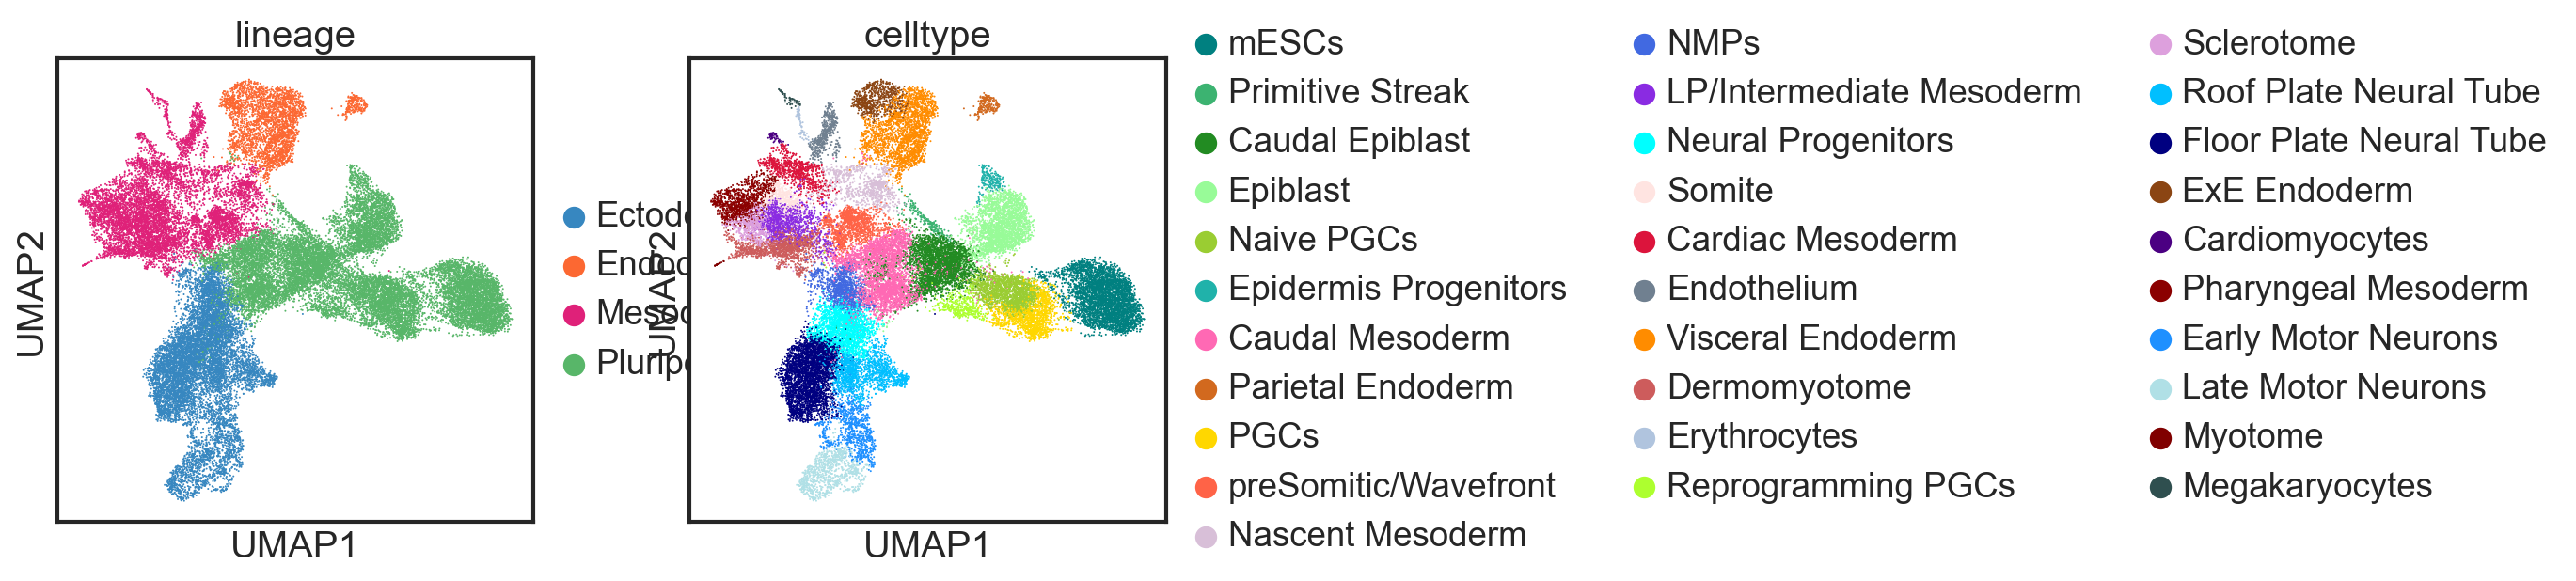

In [6]:
sc.pl.umap(adata, color = ['lineage', 'celltype'])

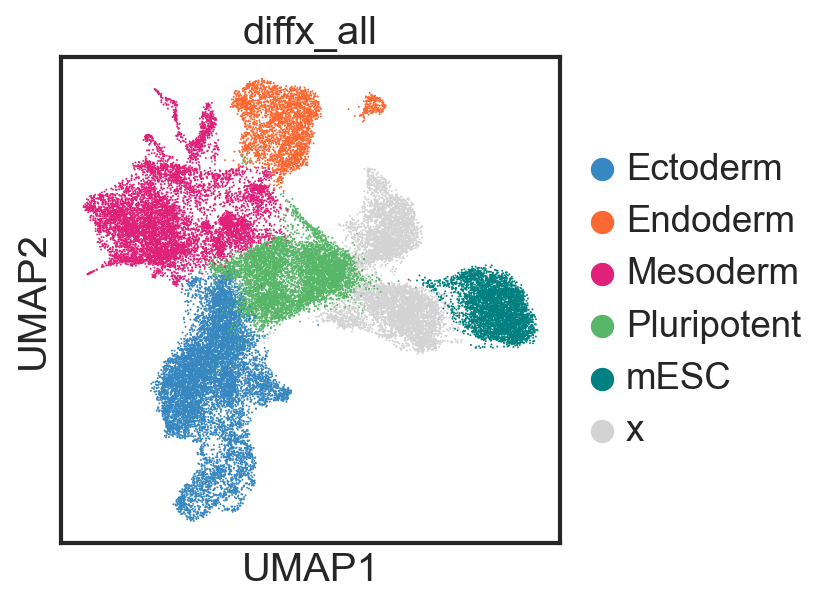

In [7]:
dict_ct = {'Mesoderm':'Mesoderm',
 'Ectoderm':'Ectoderm',
 'Endoderm':'Endoderm',
           'Pluripotent':'Pluripotent'}

adata.obs['diffx_all'] = (
    adata.obs["lineage"]
    .map(lambda x: dict_ct.get(x, x))
    .astype("category")
)

adata.obs['diffx_all'] = adata.obs['diffx_all'].astype(str)
adata.obs.loc[list(adata[adata.obs['celltype'] == 'mESCs'].obs.index), 'diffx_all'] = 'mESC'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'PGCs'].obs.index), 'diffx_all'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epidermis Progenitors'].obs.index), 'diffx_all'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epiblast'].obs.index), 'diffx_all'] = 'x'

cols = ['#3787c0', '#fc6832','#df2179', '#58b669','teal','lightgrey']
sc.pl.umap(adata, color = 'diffx_all', palette = cols )

## all comparisons

In [8]:
dict_ct = {'Mesoderm':'x','Ectoderm':'x','Endoderm':'x',
           'Pluripotent':'Pluripotent','x':'x','mESC':'mESC'}
adata.obs['diffx_ESC_p'] = (adata.obs["diffx_all"].map(lambda x: dict_ct.get(x, x)).astype("category"))


dict_ct = {'Mesoderm':'diff','Ectoderm':'diff','Endoderm':'diff',
           'Pluripotent':'Pluripotent','x':'x','mESC':'x'}
adata.obs['diffx_p_diff'] = (adata.obs["diffx_all"].map(lambda x: dict_ct.get(x, x)).astype("category"))

dict_ct = {'Mesoderm':'Mesoderm','Ectoderm':'Ectoderm','Endoderm':'Endoderm',
           'Pluripotent':'Pluripotent','x':'x','mESC':'x'}
adata.obs['diffx_diff_p'] = (adata.obs["diffx_all"].map(lambda x: dict_ct.get(x, x)).astype("category"))

adata.uns['diffx_ESC_p_colors'] = ['#58b669','teal','lightgrey']
adata.uns['diffx_p_diff_colors'] = ['#58b669','#df2179','lightgrey']
adata.uns['diffx_diff_p_colors'] = ['#3787c0', '#fc6832','#df2179', '#58b669','lightgrey']

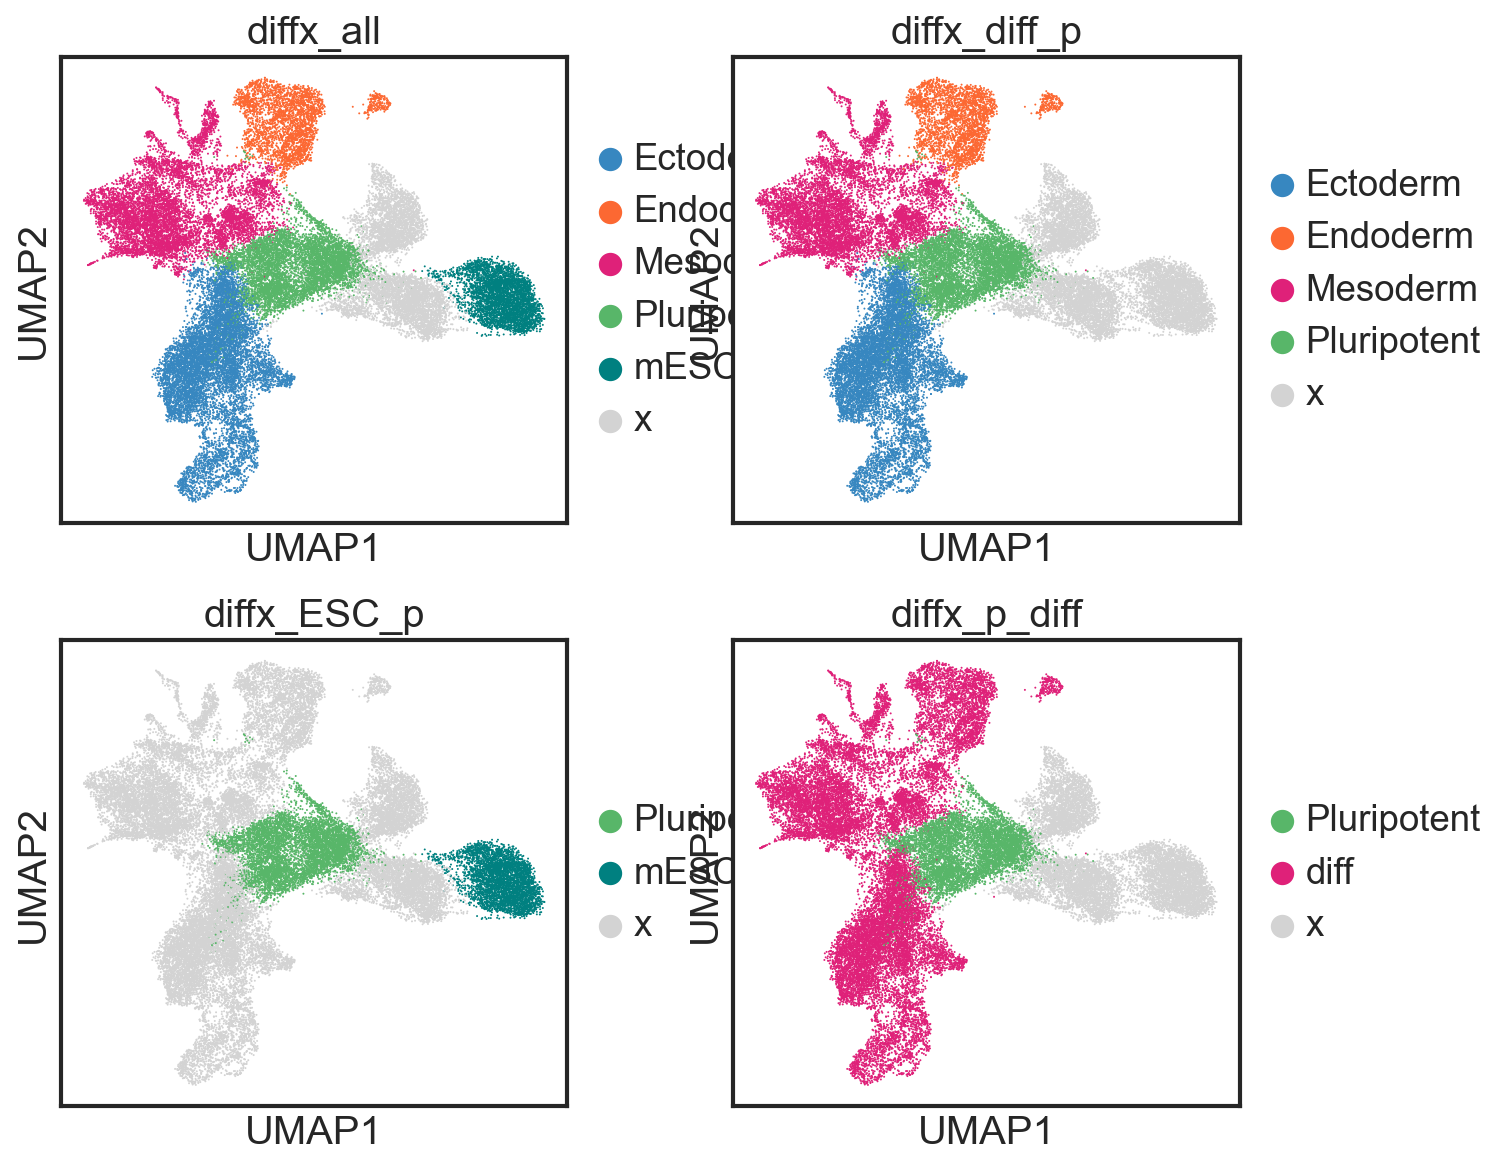

In [9]:
sc.pl.umap(adata, color = ['diffx_all','diffx_diff_p','diffx_ESC_p','diffx_p_diff'], ncols = 2)

In [10]:
adata.obs['rep'] = adata.obs['batch'].str.rsplit('-', expand=True)[6].replace({'12':'6', '11':'5','10':'4','9':'3','8':'2','7':'1'})


In [12]:
sc.settings.verbosity = 2

# start decoupler
make pseudobulks, filter, run pydeseq

## Identify and isolate groups to compare
Add back raw counts before pseudobulking - first group cells into pseudobulks, then normalise and log-transform counts again

In [13]:
groups = 'diffx_diff_p'
reps = 'rep'

In [14]:
adata.X = adata.layers['matrix']

In [15]:
# only keep cells annotated in diffx
adata_f = adata[adata.obs[groups] != 'x']

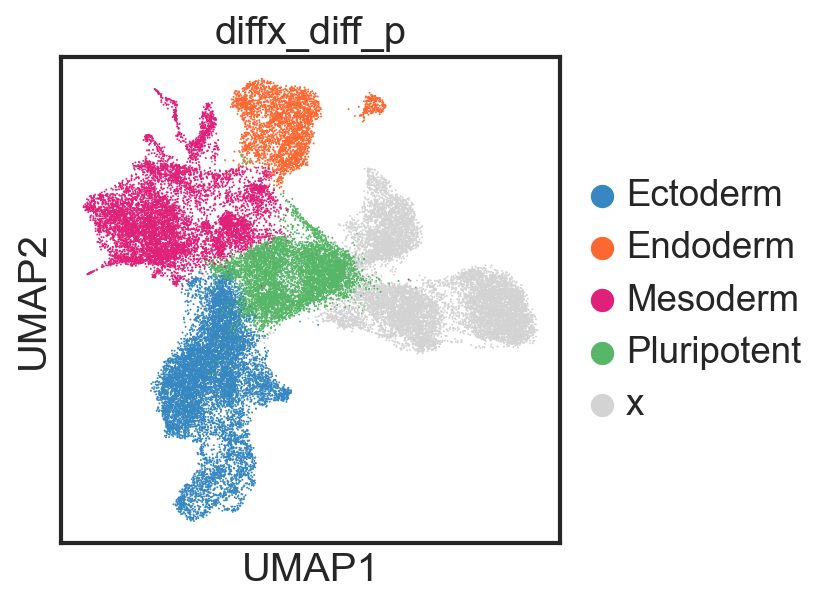

/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


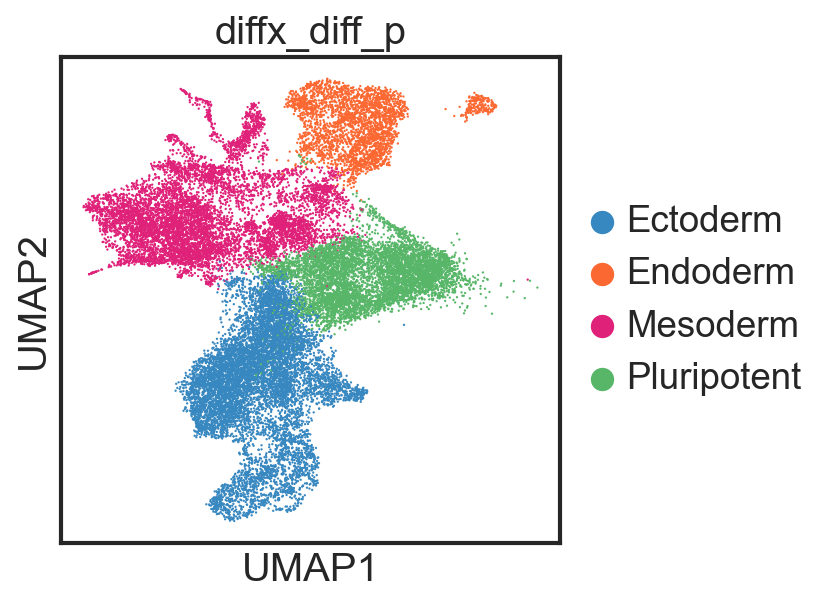

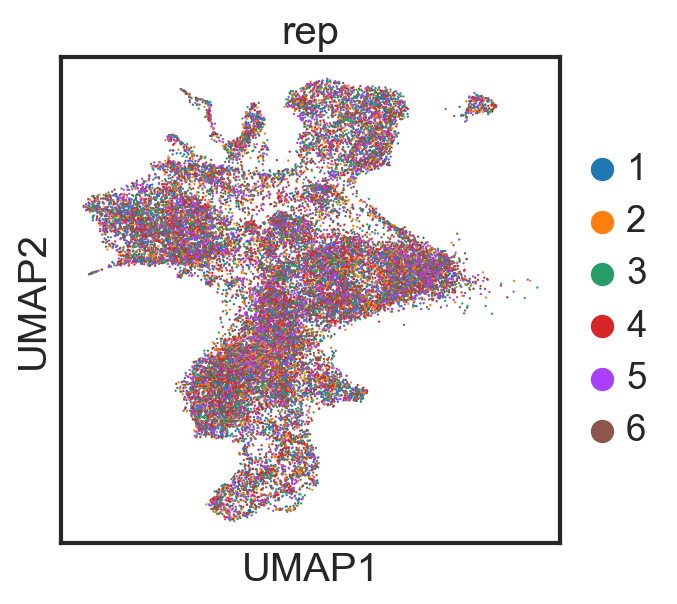

In [16]:
sc.pl.umap(adata, color = groups)
sc.pl.umap(adata_f, color = groups)
sc.pl.umap(adata_f, color = reps)

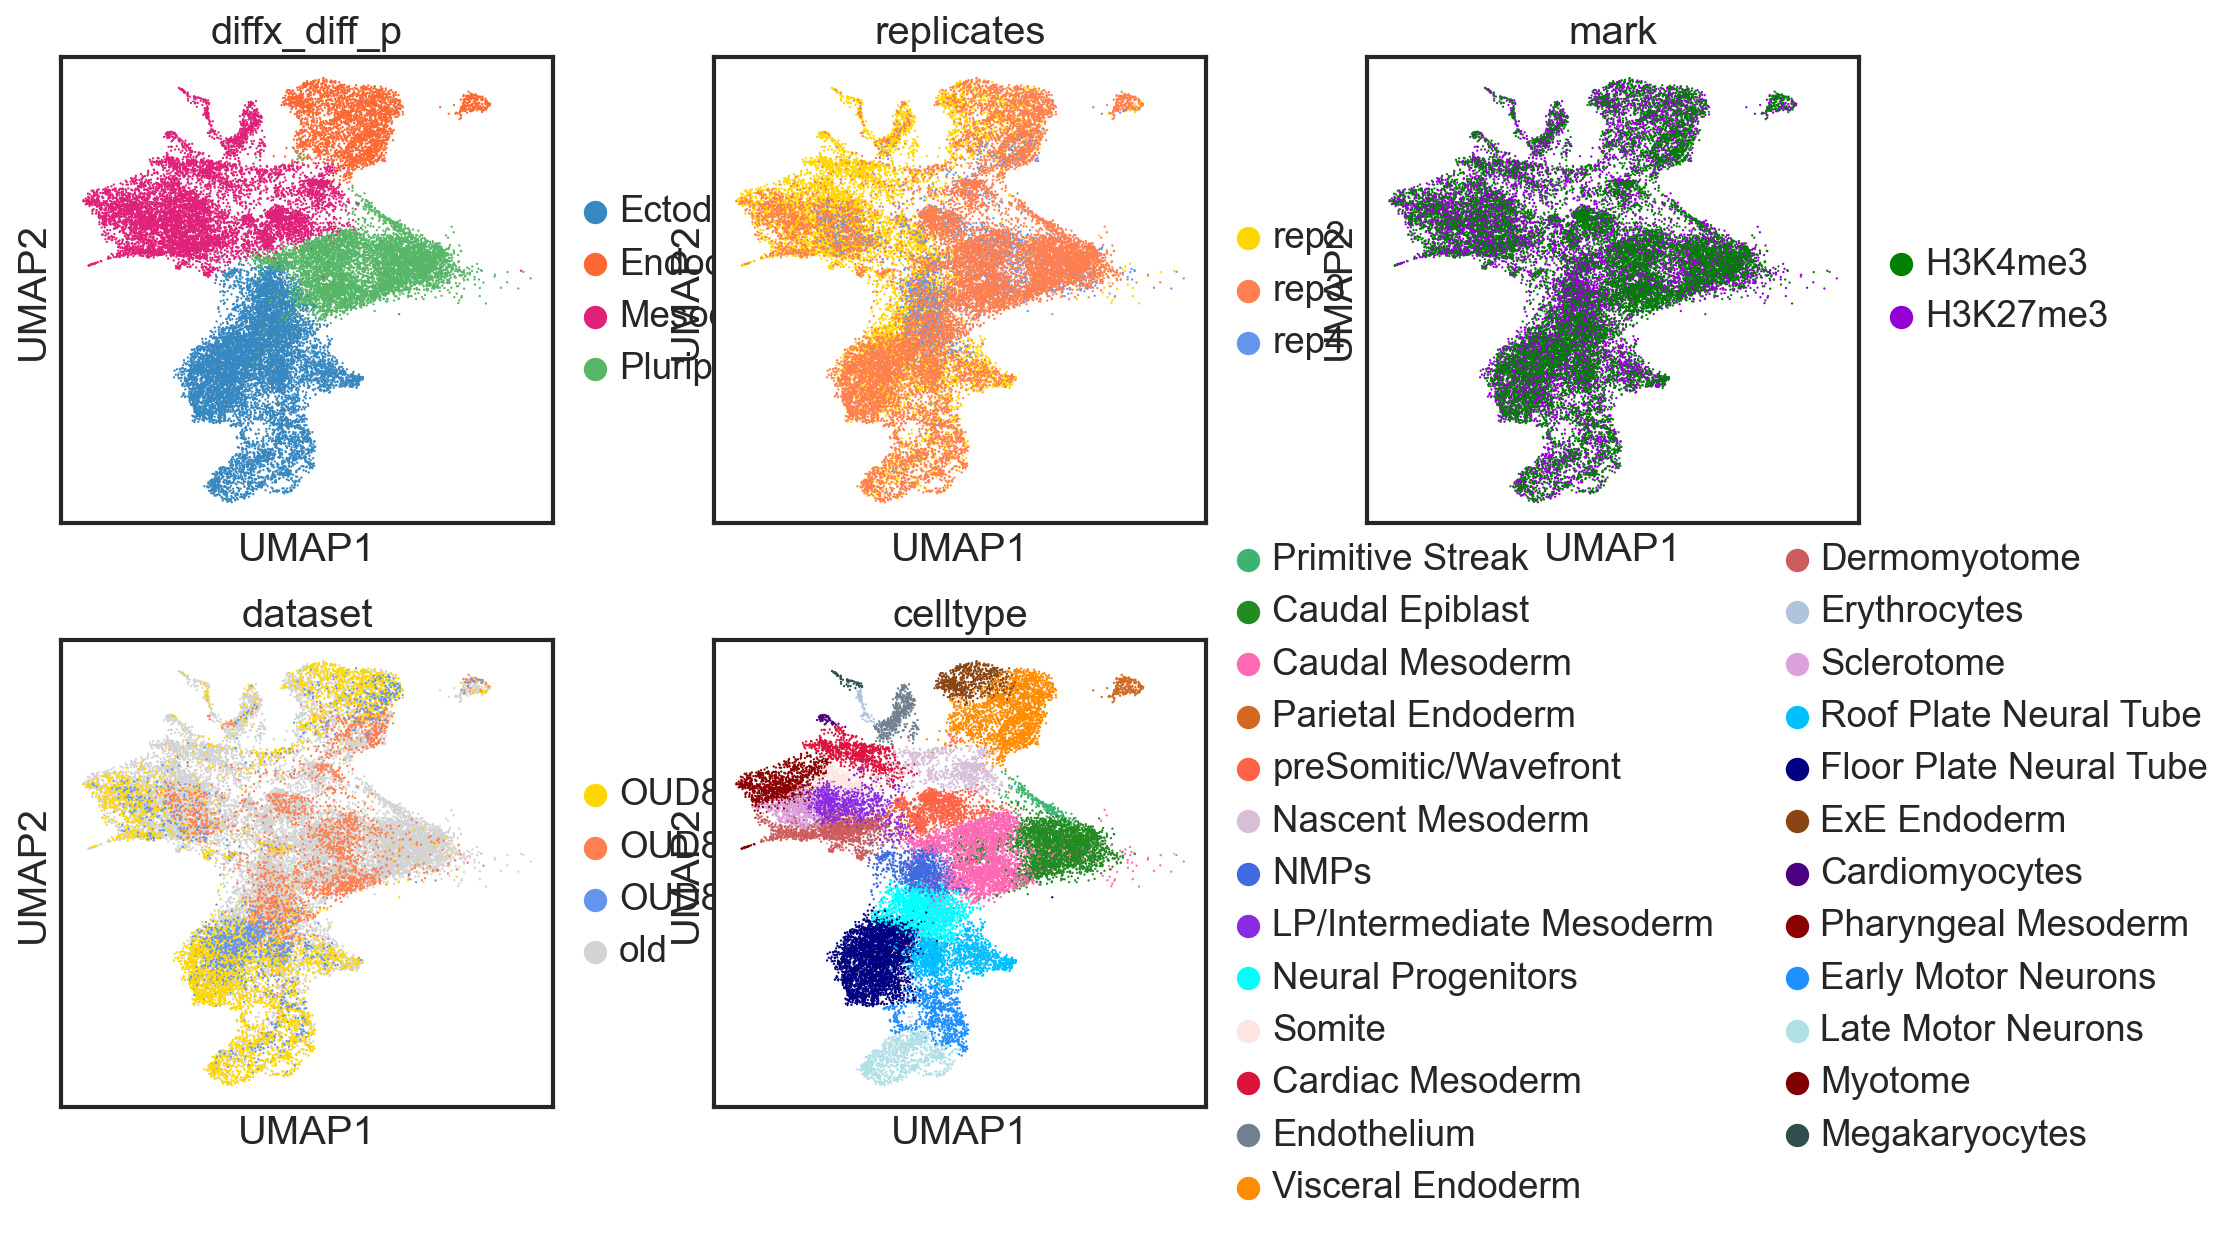

In [17]:
sc.pl.umap(adata_f, color = [groups,'replicates','mark','dataset','celltype'],ncols=3)

## define pseudobulks 

In [18]:
pd.DataFrame(adata_f.obs[[groups]].value_counts())


,count
diffx_diff_p,
Ectoderm,9849
Mesoderm,8349
Pluripotent,6629
Endoderm,3000


/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_2521/3919780850.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plot = adata_f.obs[adata.obs[reps].isin(list(adata_f.obs[reps].value_counts().head(25).index))]


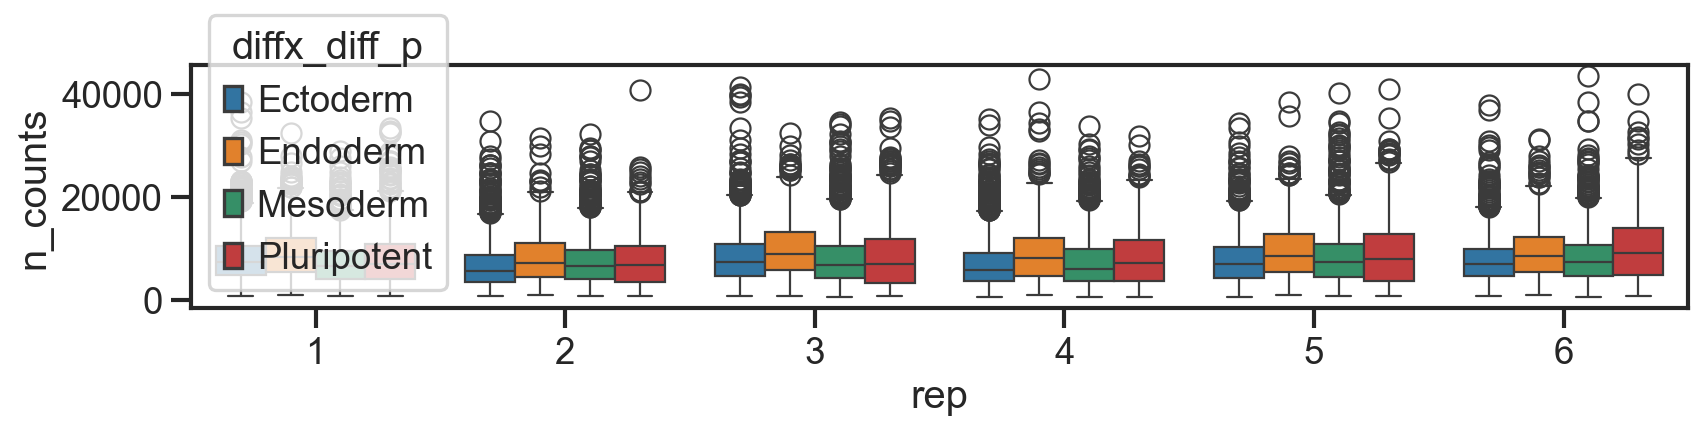

In [19]:
plot = adata_f.obs[adata.obs[reps].isin(list(adata_f.obs[reps].value_counts().head(25).index))]
plot[reps] = plot[reps].astype(str)

fig,ax = plt.subplots(figsize = (12,2))
sns.boxplot(data = plot
            ,ax=ax,
           x = reps,
           y = 'n_counts',
           hue = groups)
plt.show()

In [20]:
# Get pseudo-bulk profile
pdata = dc.get_pseudobulk(
    adata_f,
    groups_col= groups,
    sample_col= reps,
    mode='mean',
    min_cells=10,
    min_counts=0
)


/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/decoupler/plotting.py:980: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, title=grp)
/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/decoupler/plotting.py:980: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, title=grp)


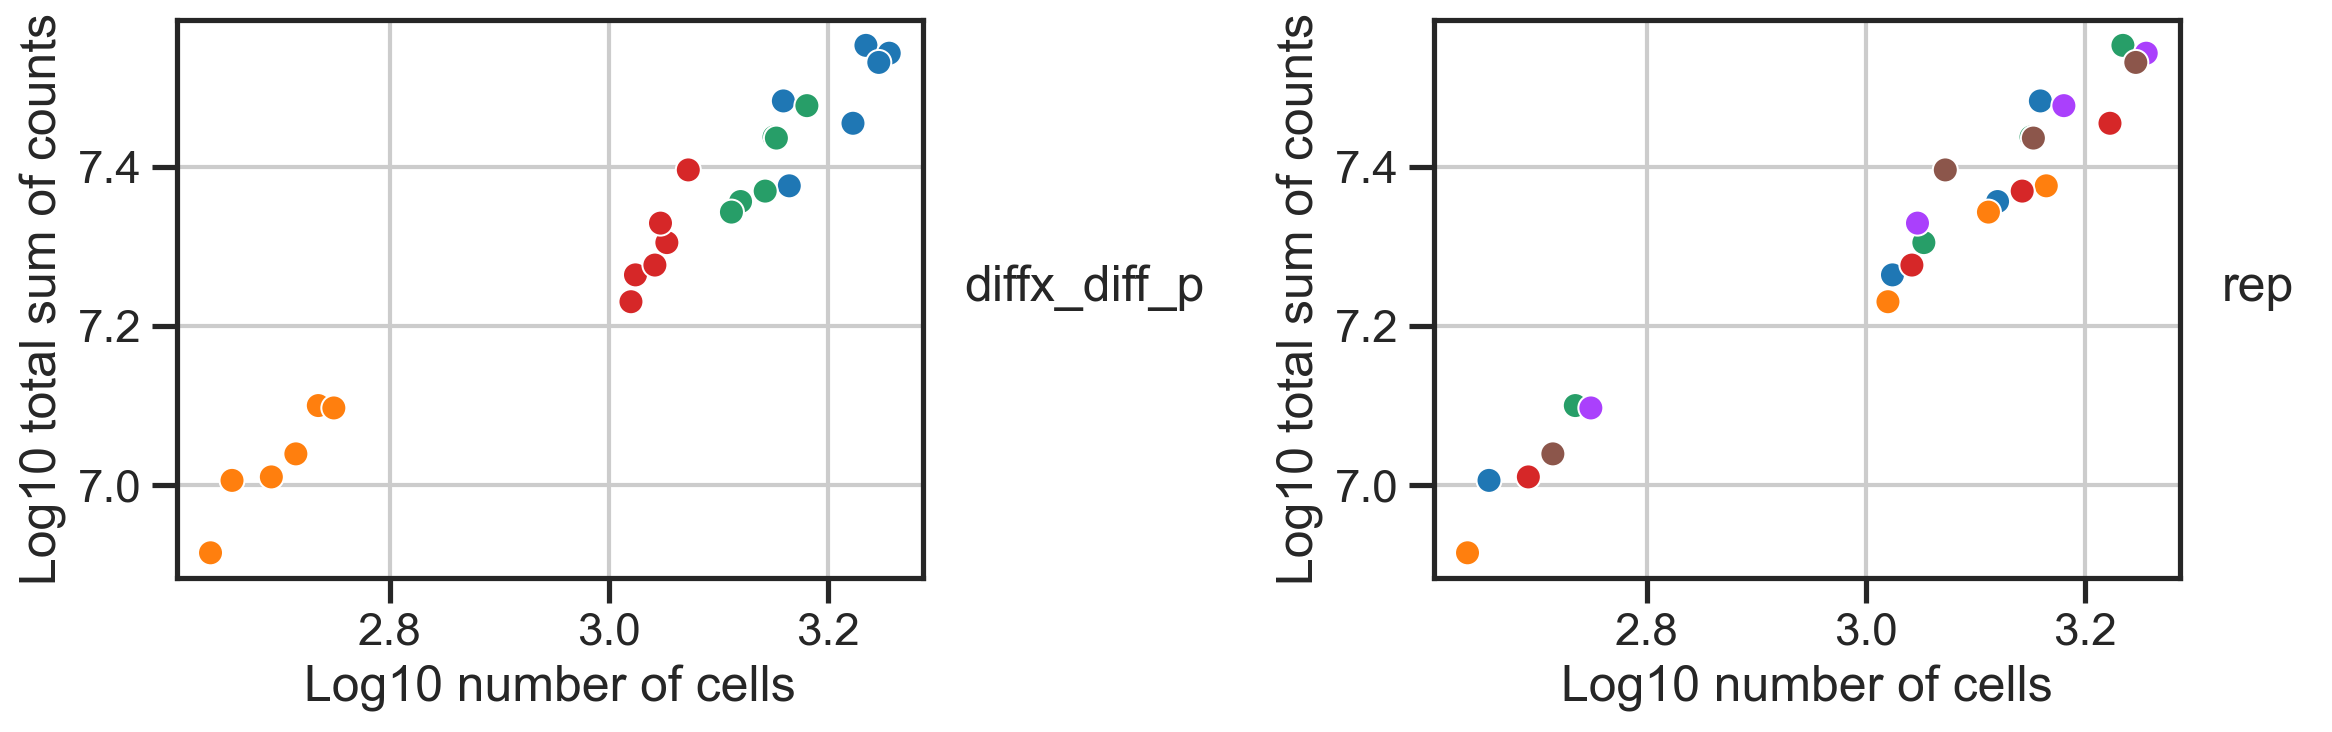

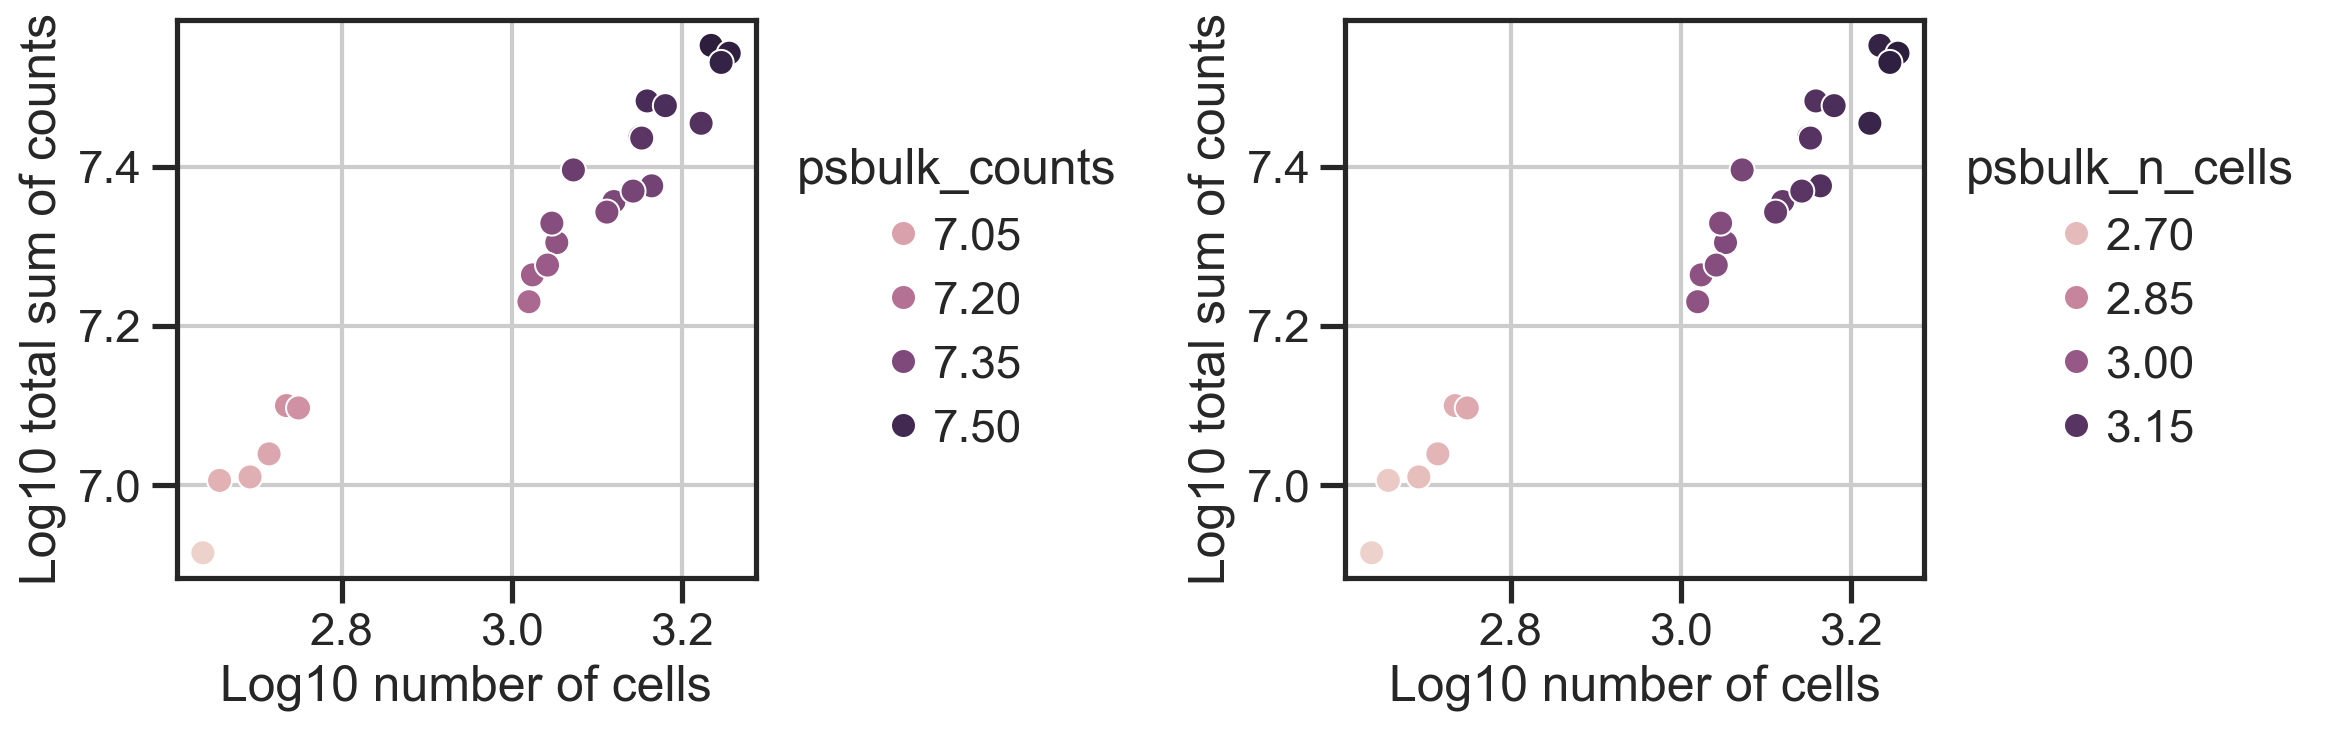

In [21]:
dc.plot_psbulk_samples(pdata, groupby=[groups, reps],figsize=(12, 4), legend = None)
plt.show()
dc.plot_psbulk_samples(pdata, groupby=['psbulk_counts','psbulk_n_cells'], figsize=(12, 4))
plt.show()


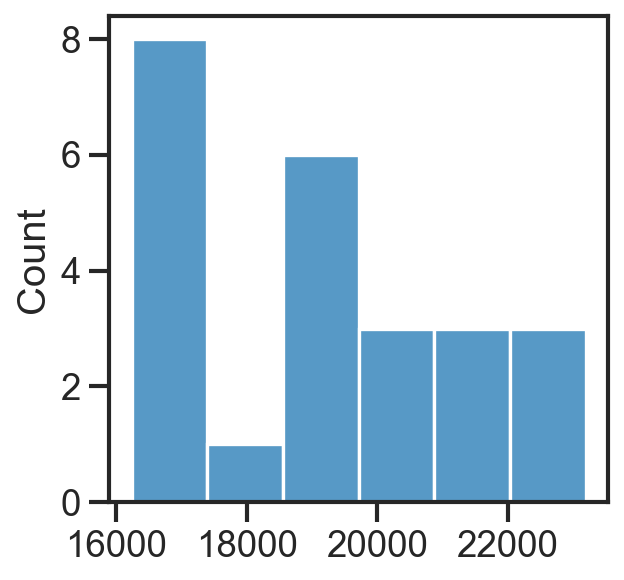

In [22]:
sns.histplot(pdata.obs['psbulk_counts']/pdata.obs['psbulk_n_cells'])
plt.show()

## filter pseudobulks

In [23]:
count_cutoff = 300000
cell_cutoff = 50

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_2521/618031605.py:5: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.stripplot(data = pdata.obs,


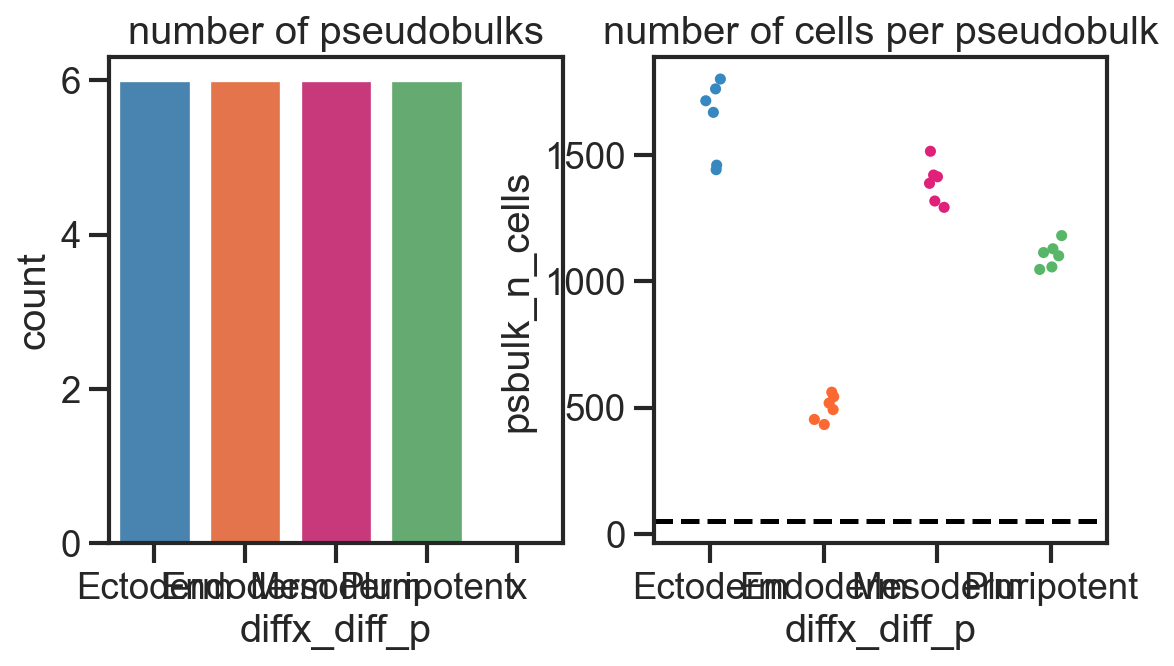

In [24]:
fig,ax = plt.subplots(1,2,figsize = (8,4))
sns.barplot(pdata.obs[groups].value_counts(),ax=ax[0],
            order= adata.obs[groups].cat.categories, palette = adata.uns[str(groups) + '_colors'])
ax[0].set_title('number of pseudobulks')
sns.stripplot(data = pdata.obs,
            x = groups,ax=ax[1],
            y = 'psbulk_n_cells', palette = adata.uns[str(groups) + '_colors'])
ax[1].axhline(cell_cutoff, c='black', linestyle='dashed')
ax[1].set_title('number of cells per pseudobulk')
plt.show()

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_2521/4039257042.py:3: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.histplot(data = pdata.obs,
/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_2521/4039257042.py:7: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.histplot(data = pdata.obs,


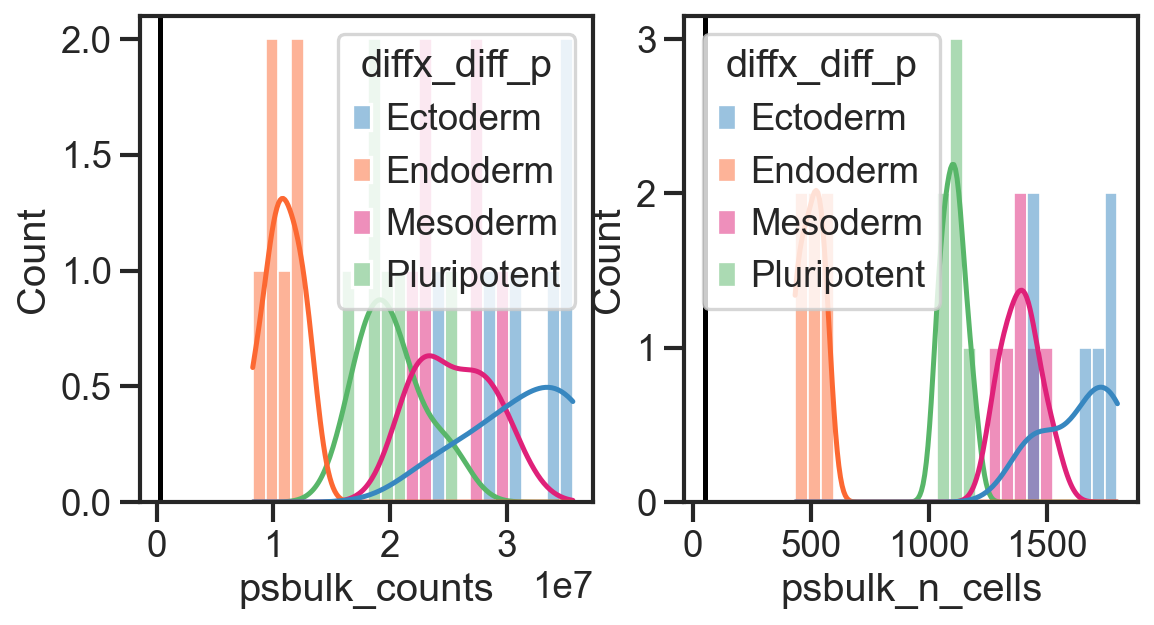

In [25]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax = ax.flatten()
sns.histplot(data = pdata.obs,
             x = 'psbulk_counts',ax=ax[0], bins = 25, hue = groups, kde = True,
             palette = adata.uns[str(groups) + '_colors'])
ax[0].axvline(count_cutoff, color = 'black')
sns.histplot(data = pdata.obs,
             x = 'psbulk_n_cells',ax=ax[1], bins = 25, hue = groups, kde = True,
             palette = adata.uns[str(groups) + '_colors'])
ax[1].axvline(cell_cutoff, color = 'black')
plt.show()

In [26]:
# Get pseudo-bulk profile
pdata = dc.get_pseudobulk(
    adata_f,
    groups_col=groups,
    sample_col=reps,
    mode='sum',
    min_cells=cell_cutoff,
    min_counts=count_cutoff
)

/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/decoupler/plotting.py:980: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, title=grp)
/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/decoupler/plotting.py:980: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, title=grp)


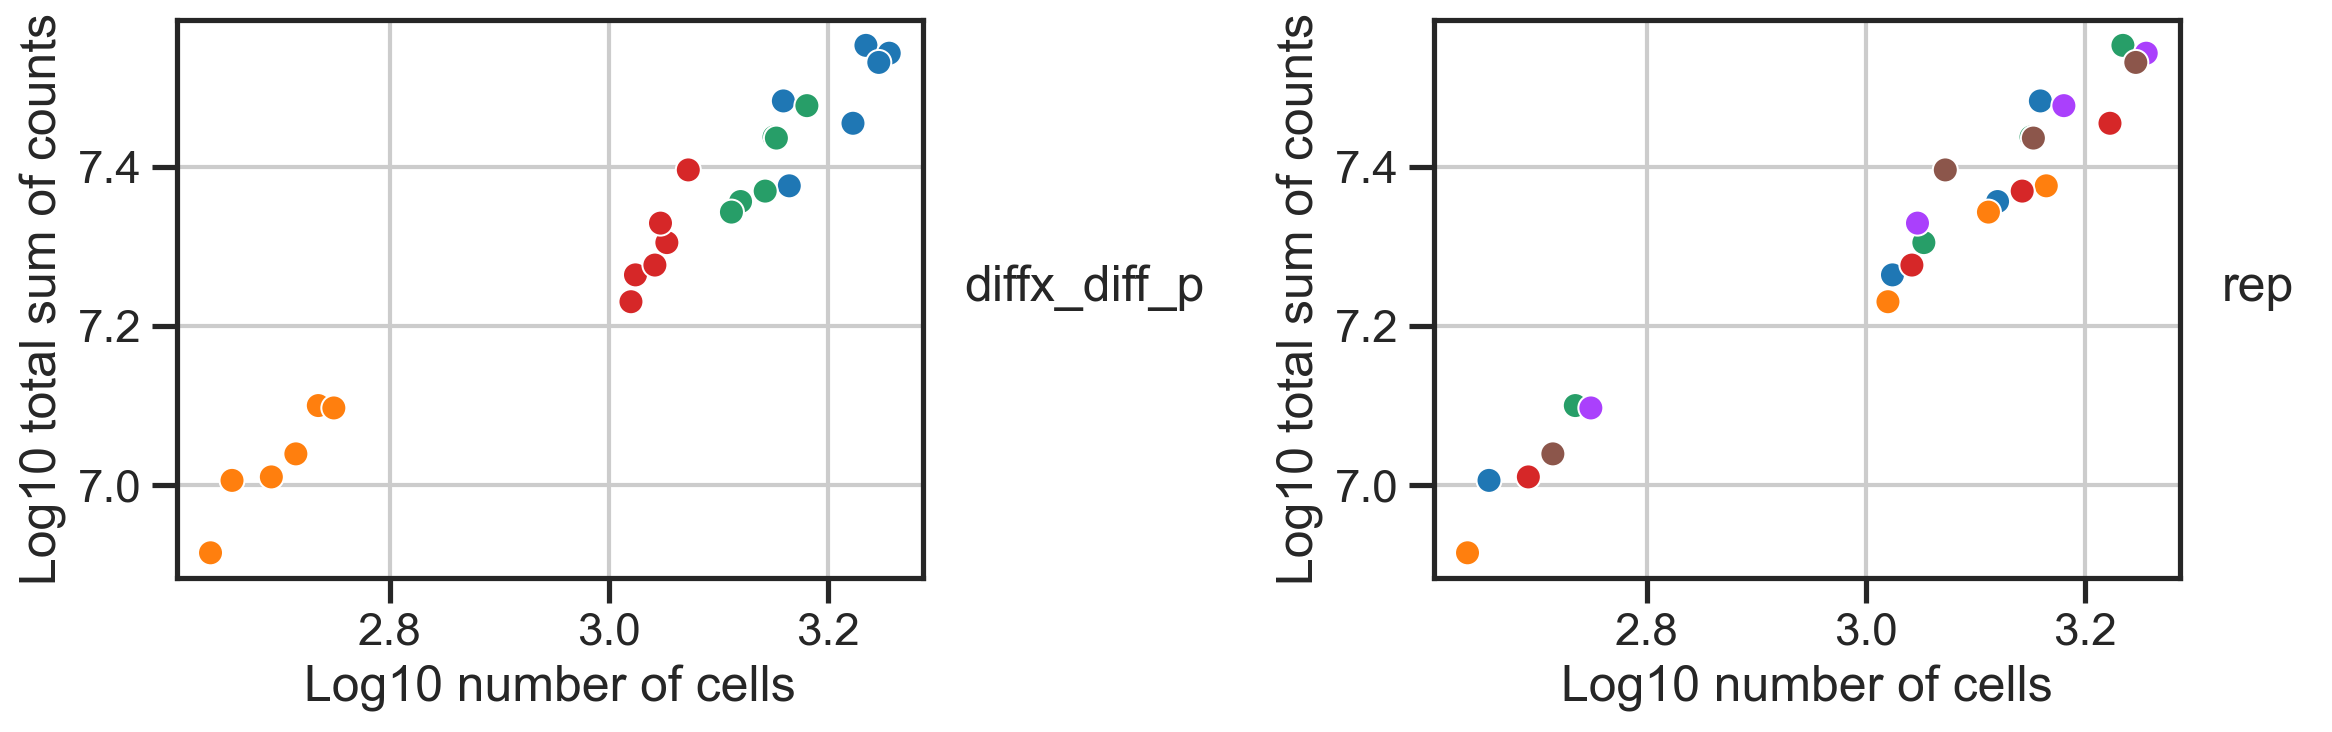

In [27]:
dc.plot_psbulk_samples(pdata, groupby=[groups,reps],figsize=(12, 4),legend = None)
plt.show()

/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_2521/425675264.py:3: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.histplot(data = pdata.obs,
/var/folders/_k/c0bkq2m10c5f4h7vq_0xfm_40000gn/T/ipykernel_2521/425675264.py:7: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.histplot(data = pdata.obs,


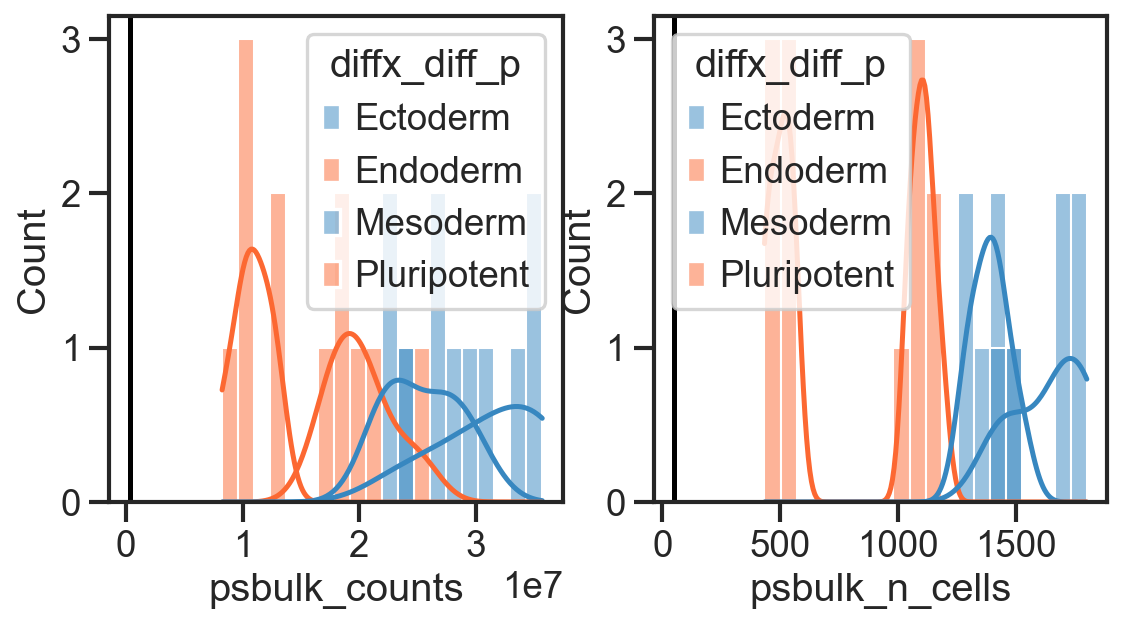

In [28]:
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax = ax.flatten()
sns.histplot(data = pdata.obs,
             x = 'psbulk_counts',ax=ax[0], bins = 20, hue = groups, kde = True, 
             palette = adata.uns[str(groups) + '_colors'][0:2])
ax[0].axvline(count_cutoff, color = 'black')
sns.histplot(data = pdata.obs,
             x = 'psbulk_n_cells',ax=ax[1], bins = 20, hue = groups, kde = True,
             palette = adata.uns[str(groups) + '_colors'][0:2])
ax[1].axvline(cell_cutoff, color = 'black')
plt.show()

## normalise and log-transform counts

In [29]:
# Store raw counts in layers
pdata.layers['counts'] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.swap_layer(pdata, 'counts', X_layer_key=None, inplace=True)


normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=23
    finished (0:00:00)


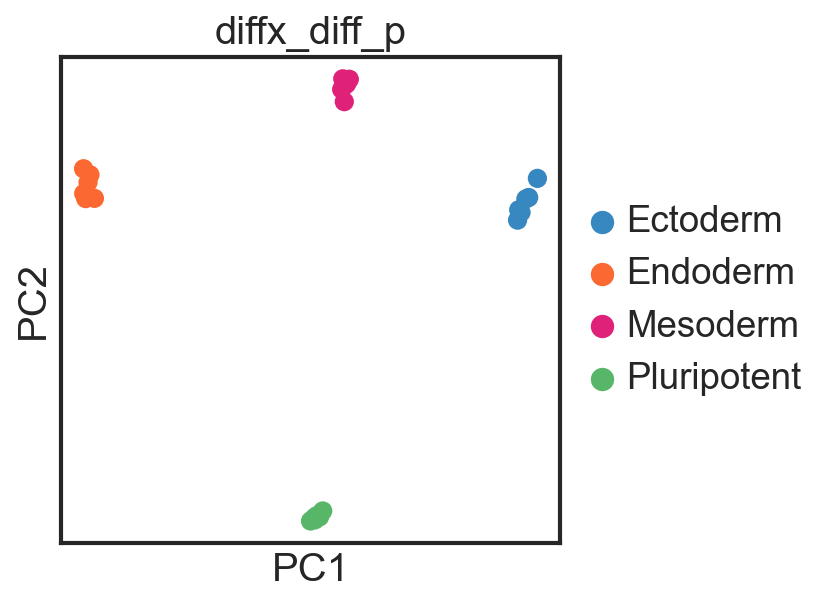

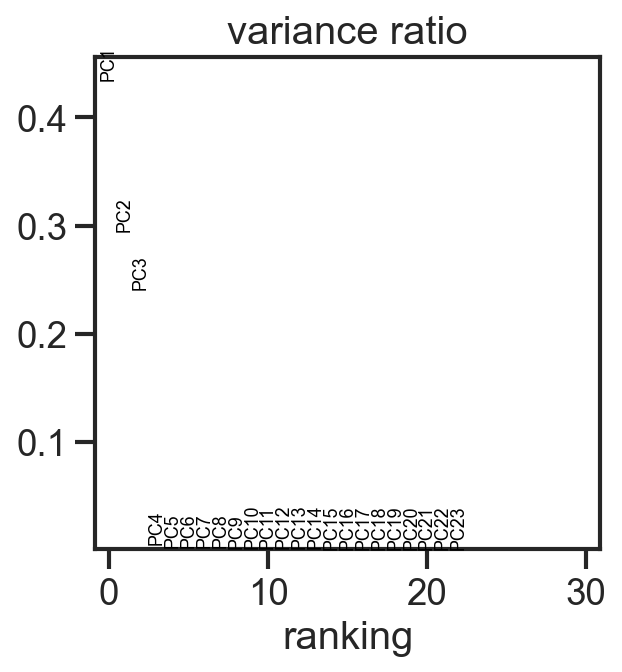

In [30]:
sc.pl.pca(pdata, color=[groups], ncols=3, size=300, palette = adata.uns[str(groups) + '_colors'])
sc.pl.pca_variance_ratio(pdata)



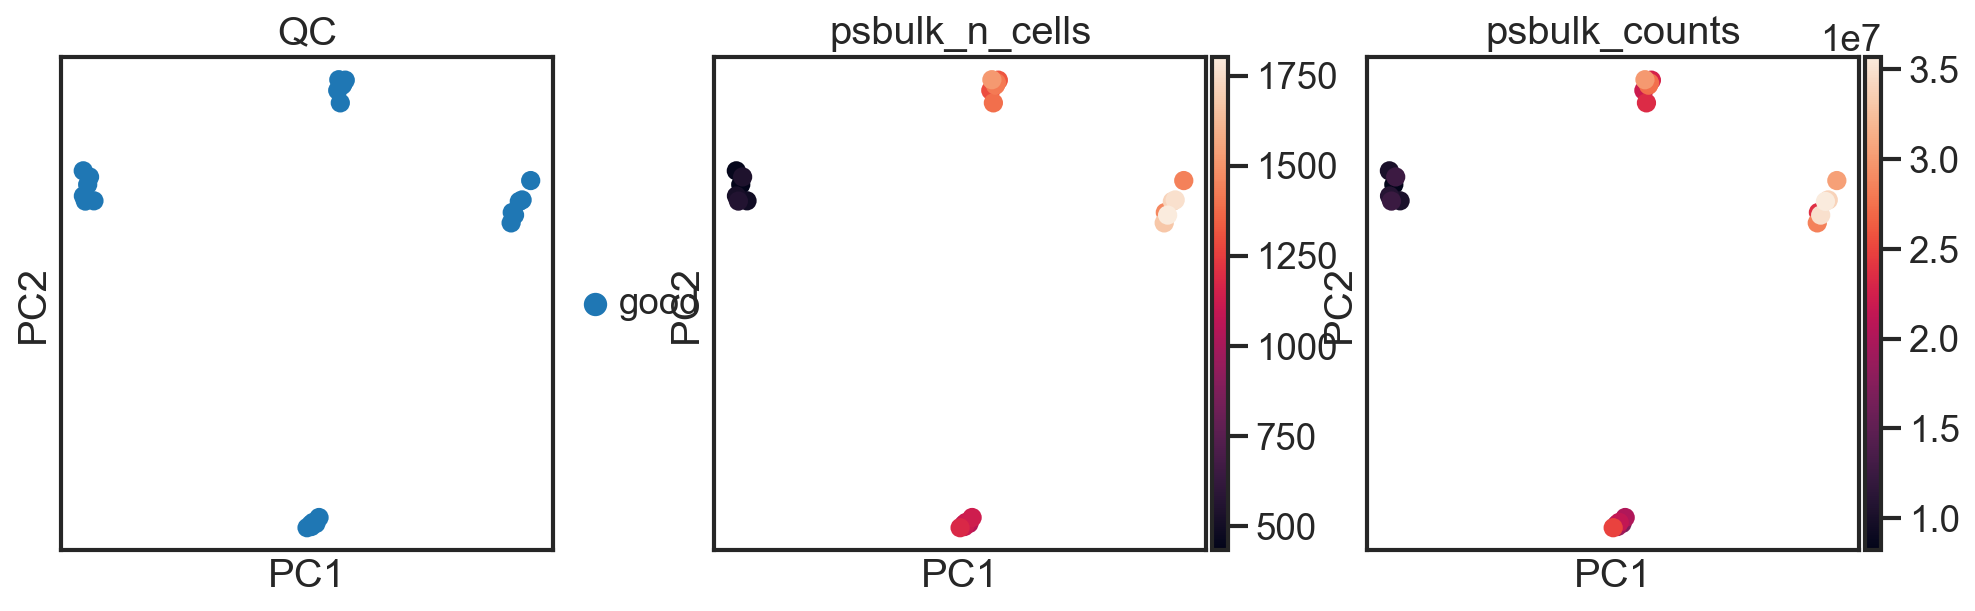

In [31]:
sc.pl.pca(pdata, color=['QC','psbulk_n_cells', 'psbulk_counts'], ncols=3, size=300)


## perform feature (gene) filtering

In [32]:
count_cutoff = 5
total_cutoff = 250

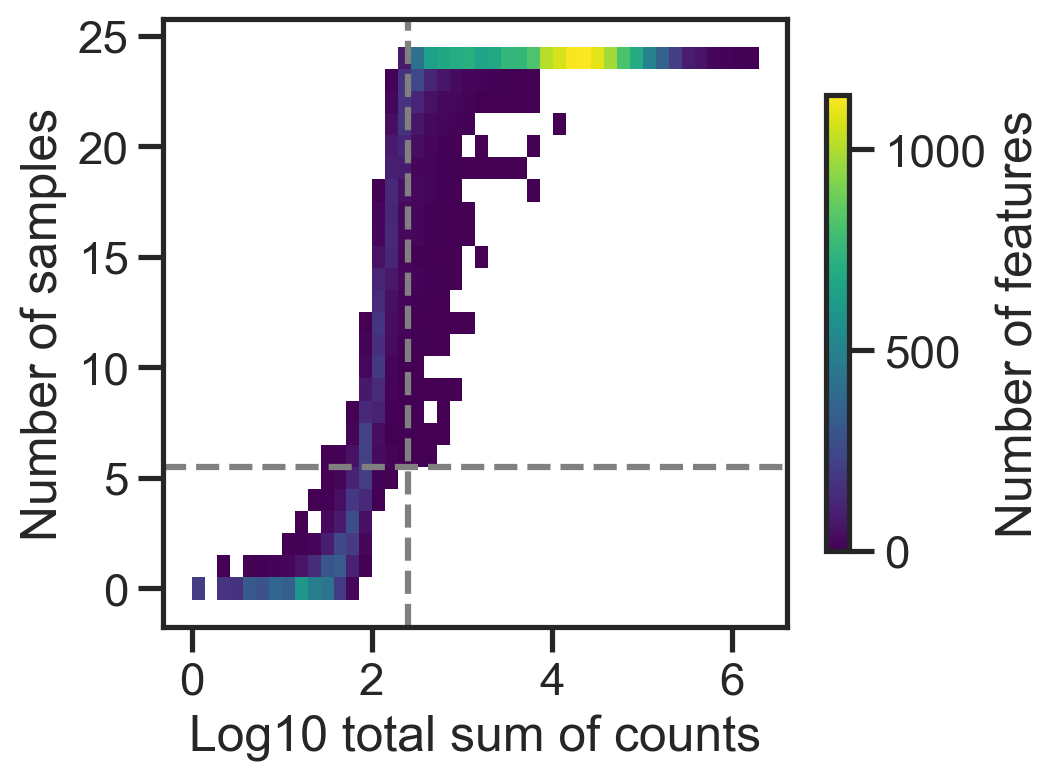

In [33]:
dc.plot_filter_by_expr(pdata, group=groups, min_count=count_cutoff, min_total_count=total_cutoff)
plt.show()

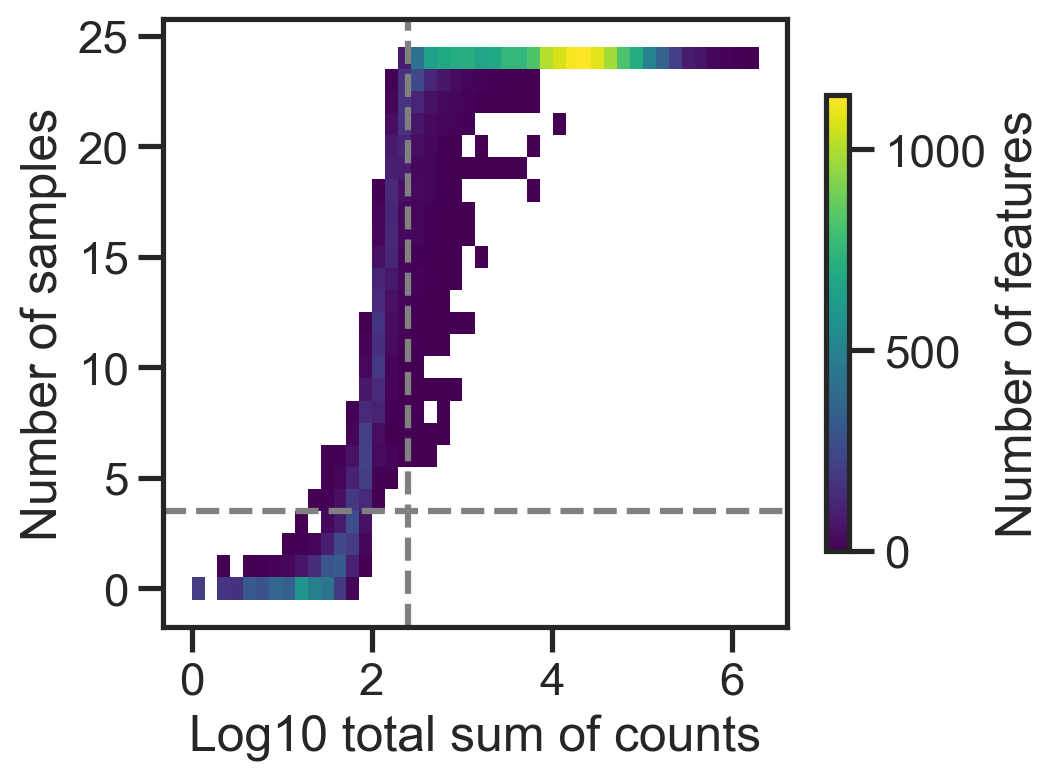

In [34]:
dc.plot_filter_by_expr(pdata, group=reps, min_count=count_cutoff, min_total_count=total_cutoff)
plt.show()

In [35]:
pdata

AnnData object with n_obs × n_vars = 24 × 27278
    obs: 'rep', 'diffx_diff_p', 'lineage', 'QC', 'diffx_all', 'diffx_ESC_p', 'diffx_p_diff', 'psbulk_n_cells', 'psbulk_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'pca', 'diffx_diff_p_colors', 'QC_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [36]:
# Obtain genes that pass the thresholds
genes = dc.filter_by_expr(pdata, group=groups, min_count=count_cutoff, min_total_count=total_cutoff)

# Filter by these genes
pdata = pdata[:, genes].copy()
pdata

AnnData object with n_obs × n_vars = 24 × 17418
    obs: 'rep', 'diffx_diff_p', 'lineage', 'QC', 'diffx_all', 'diffx_ESC_p', 'diffx_p_diff', 'psbulk_n_cells', 'psbulk_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'pca', 'diffx_diff_p_colors', 'QC_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

## start DEseq differential analysis

In [37]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=1)
dds = DeseqDataSet(
    adata=pdata,
    design=groups,
   # ref_level=list(pdata.obs[groups].unique()),
    refit_cooks=True,
    inference=inference,
)

In [38]:
# Compute LFCs
dds.deseq2()

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 5.61 seconds.

Fitting dispersion trend curve...
... done in 0.19 seconds.

Fitting MAP dispersions...
... done in 6.14 seconds.

Fitting LFCs...
... done in 1.98 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [39]:
list(pdata.obs[groups].unique())[-1]

'Pluripotent'

In [40]:
# Extract contrast between LINS vs ESC
stat_res = DeseqStats(
    dds,
    contrast=[groups] +  [list(pdata.obs[groups].unique())[-1]] + list(pdata.obs[groups].unique())[0:3],
    inference=inference,
)

In [41]:
# Compute Wald test
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: diffx_diff_p Pluripotent vs Ectoderm
                  baseMean  log2FoldChange     lfcSE       stat        pvalue  \
Gene                                                                            
0610009B22Rik   207.484330       -0.036818  0.071643  -0.513908  6.073164e-01   
0610009E02Rik    96.823848        0.022464  0.095115   0.236173  8.132985e-01   
0610009L18Rik    52.572609       -0.177759  0.142436  -1.247990  2.120346e-01   
0610012G03Rik   256.452904        0.063996  0.066789   0.958183  3.379705e-01   
0610030E20Rik   402.371186       -0.397646  0.052488  -7.575888  3.566782e-14   
...                    ...             ...       ...        ...           ...   
Zyx            1254.732580        0.960396  0.045337  21.183277  1.362176e-99   
Zzef1          1511.842001       -0.509329  0.047117 -10.809818  3.092841e-27   
Zzz3           4418.997413       -0.074876  0.017592  -4.256180  2.079493e-05   
a               362.379792       -

... done in 0.75 seconds.



In [42]:
# Extract results
results_df = stat_res.results_df

results_df.head(2)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
0610009B22Rik,207.484330,-0.036818,0.071643,-0.513908,0.607316,0.651129
0610009E02Rik,96.823848,0.022464,0.095115,0.236173,0.813298,0.838723


/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


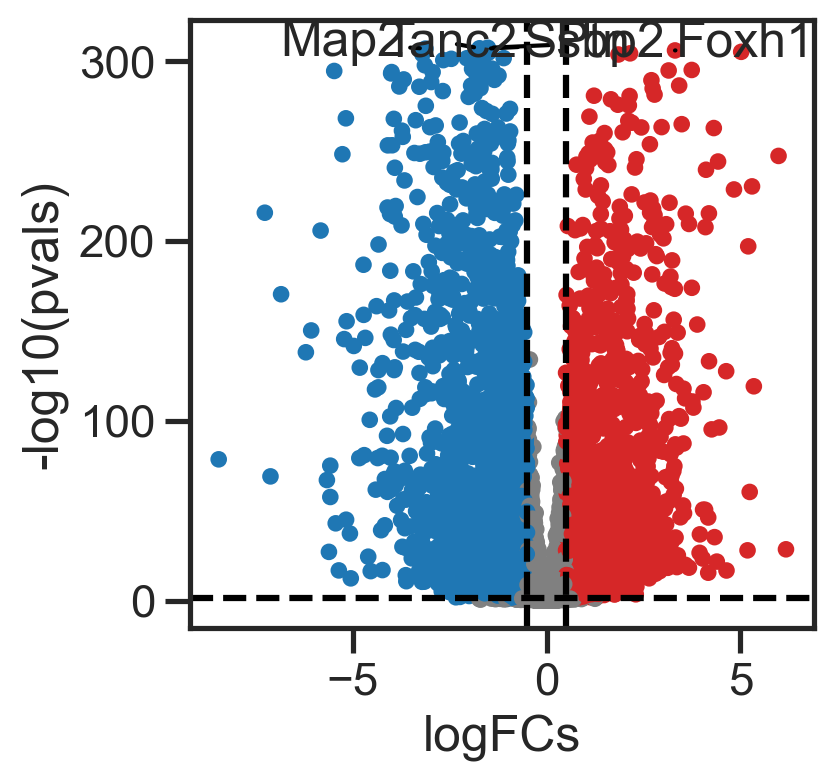

In [43]:

dc.plot_volcano_df(
    results_df,
    x='log2FoldChange',
    y='padj',
    top=5,
    figsize=(4,4)
)
plt.show()

## Identify diff expressed genes

In [44]:
results_df['p_log10'] = -np.log10(results_df['padj'])
results_df = results_df[np.isfinite(results_df['p_log10'])]


up = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] > 2)].sort_values(by = 'log2FoldChange',ascending=True)

down = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] < -2)].sort_values(by = 'log2FoldChange',ascending=True)


/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [45]:
up.shape

(407, 7)

In [46]:
down.shape

(479, 7)

In [47]:
pdata

AnnData object with n_obs × n_vars = 24 × 17418
    obs: 'rep', 'diffx_diff_p', 'lineage', 'QC', 'diffx_all', 'diffx_ESC_p', 'diffx_p_diff', 'psbulk_n_cells', 'psbulk_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'pca', 'diffx_diff_p_colors', 'QC_colors', 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'X_pca', 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable'
    varm: 'PCs', '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    layers: 'psbulk_props', 'counts', 'normed_counts', '_mu_hat', 'cooks'

# do standard scanpy diff gene analysis

In [48]:
sc.tl.rank_genes_groups(adata_f, groupby = groups,method='wilcoxon')

ranking genes
    finished (0:00:38)


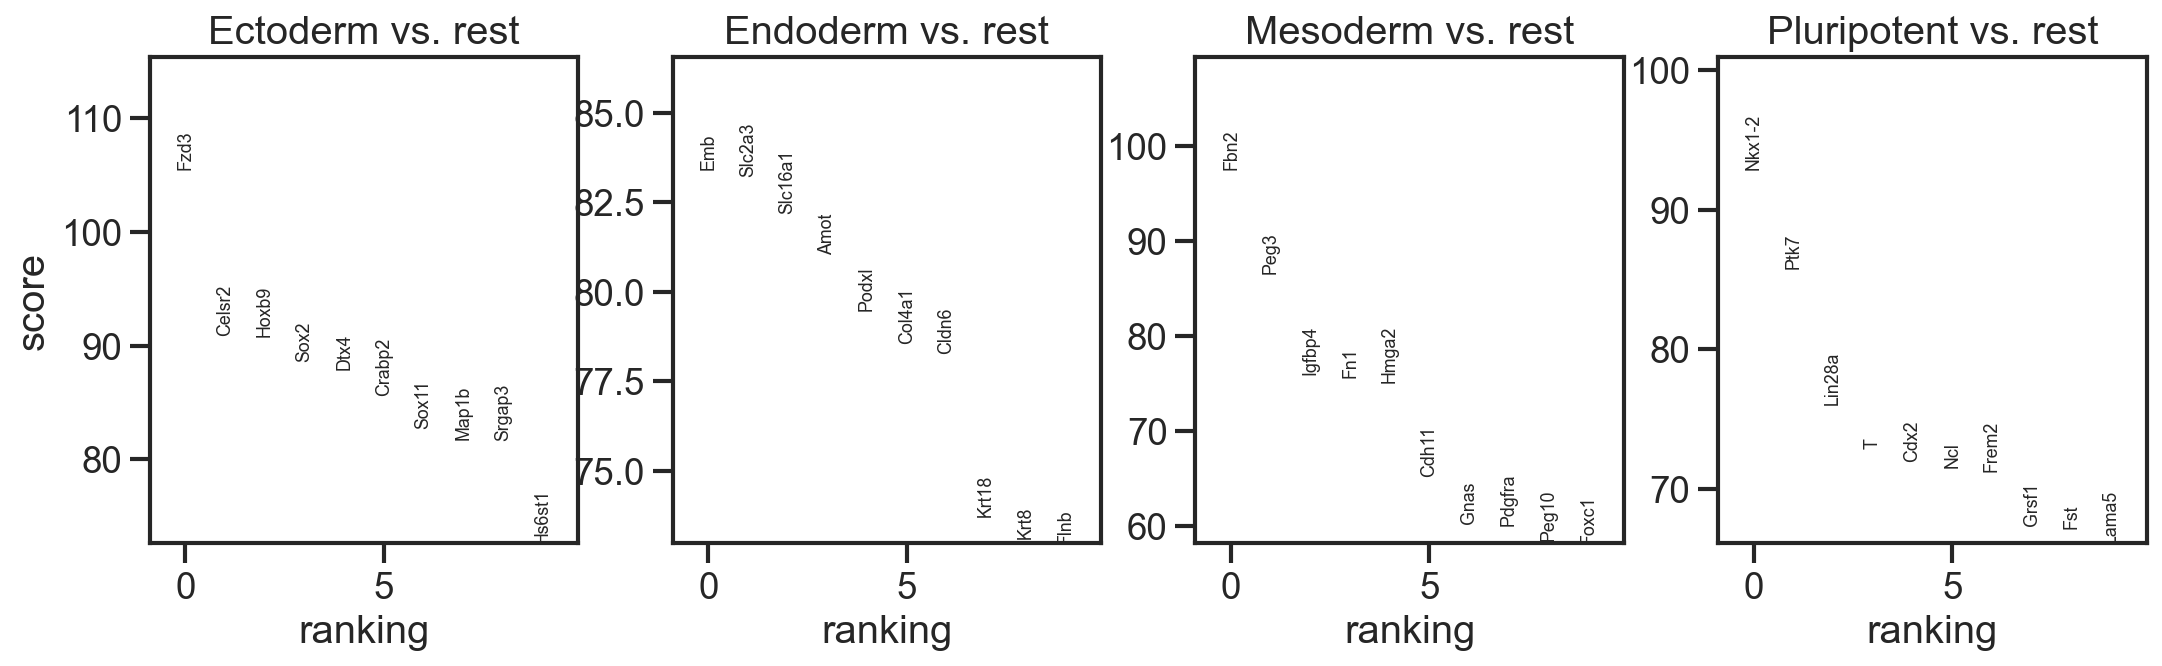

In [49]:
sc.pl.rank_genes_groups(adata_f, n_genes=10, sharey=False)


    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_diffx_diff_p']`


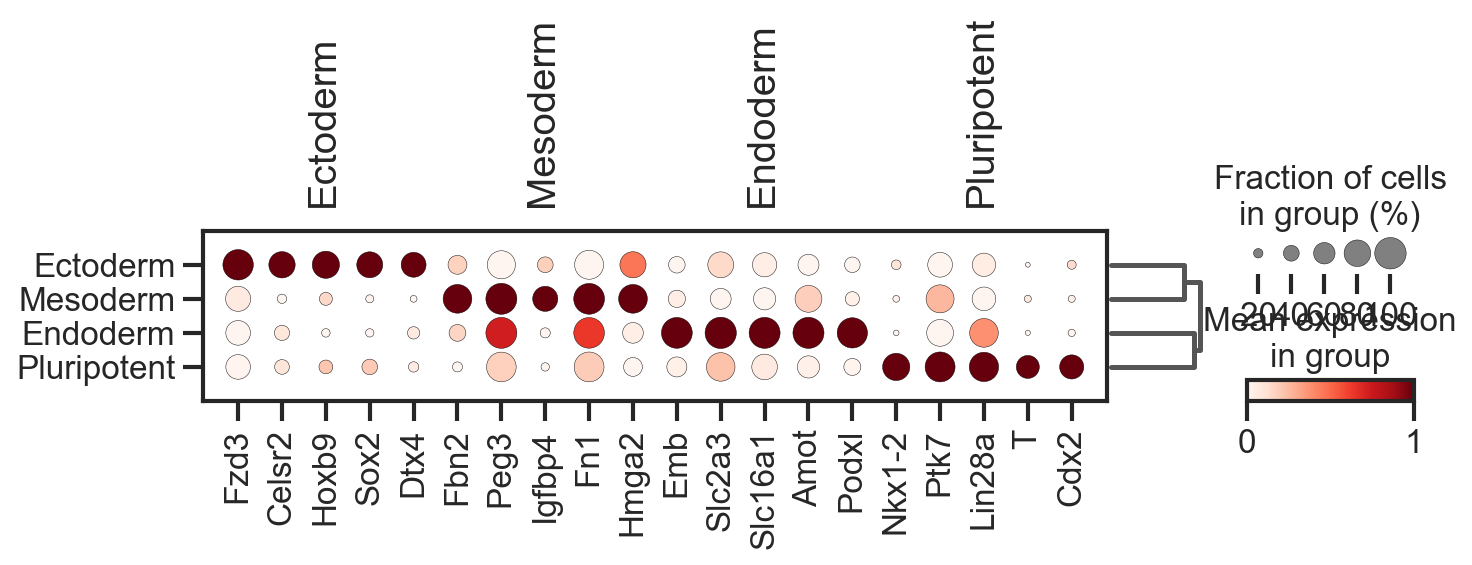

In [50]:
sc.pl.rank_genes_groups_dotplot(
    adata_f, groupby=groups, standard_scale="var", n_genes=5
)
plt.show()

In [51]:
def diff_exp_matrices(lin):
    de = sc.get.rank_genes_groups_df(adata_f, group=lin)
    de.index = de['names']
    de = de.rename(columns = {'logfoldchanges':'log2FoldChange', 'pvals_adj': 'padj','scores':'stat'})
    de['p_log10'] = -np.log10(de['padj'])
    #diff_exp = diff_exp[np.isfinite(diff_exp['p_log10'])]
    de_up = de[(de['log2FoldChange'] > 2) & (de['padj'] < 0.05)]
    return de,de_up


In [52]:
deP,deP_up = diff_exp_matrices('Pluripotent')
deEC,deEC_up = diff_exp_matrices('Ectoderm')
deEN,deEN_up = diff_exp_matrices('Endoderm')
deM,deM_up = diff_exp_matrices('Mesoderm')


/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [53]:
deP_up.shape

(171, 6)

In [54]:
deEC_up.shape

(314, 6)

In [55]:
deEN_up.shape

(606, 6)

In [56]:
deM_up.shape

(299, 6)

# check intersect between deseq2 and scanpy

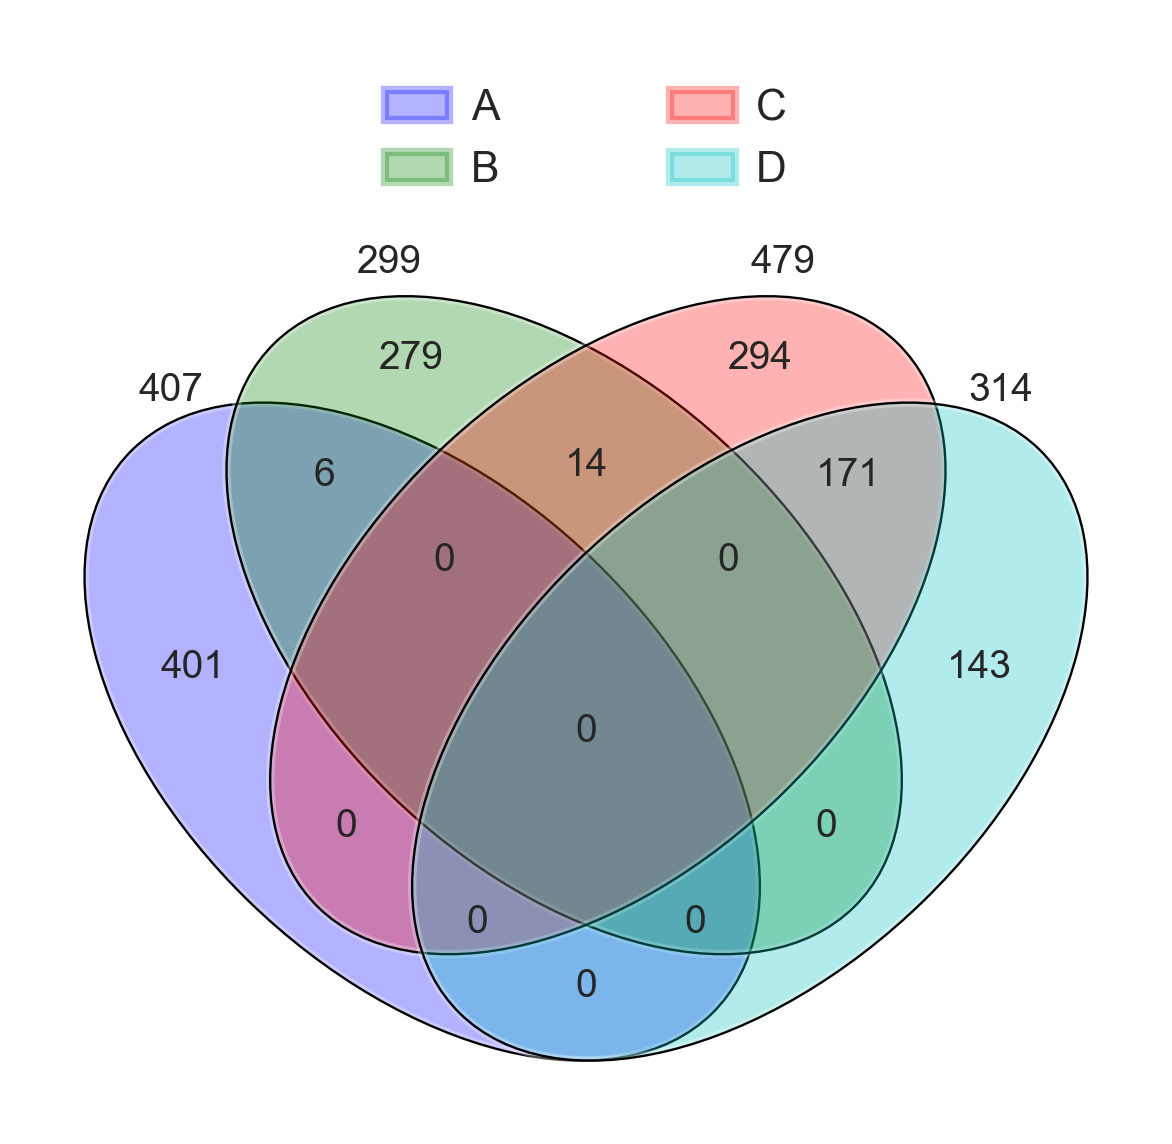

In [57]:
from venny4py.venny4py import *

#dict of sets
sets = {
    'A': set(list(up.index)),
    'B': set(list(deM_up['names'])),
    'C': set(list(down.index)),
    'D': set(list(deEC_up['names']))}
    
venny4py(sets=sets, )#colors = list(lin_colors.values()),)

#plt.savefig('figs/venn4.png',bbox_inches='tight')
plt.show()

In [58]:
sc.set_figure_params(dpi = 80)

sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

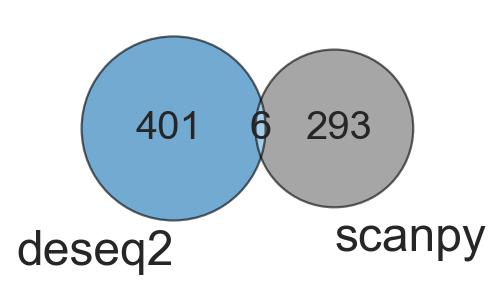

In [59]:
from matplotlib_venn import venn2, venn2_circles

A = up.index
B = deM_up['names']

fig,ax = plt.subplots(figsize = (3,3))
venn2([set(A),set(B)],ax=ax, set_colors = [adata.uns[str(groups) + '_colors'][0] , 'grey'],set_labels = ['deseq2','scanpy'],
      alpha = 0.7)
c = venn2_circles([set(A),set(B)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

#plt.savefig('figs/venn3_neg.png',bbox_inches='tight')
plt.show()

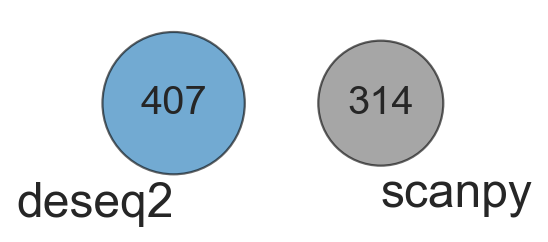

In [60]:
from matplotlib_venn import venn2, venn2_circles

A = up.index
B = deEC_up['names']

fig,ax = plt.subplots(figsize = (3,3))
venn2([set(A),set(B)],ax=ax, set_colors = [adata.uns[str(groups) + '_colors'][0] , 'grey'],set_labels = ['deseq2','scanpy'],
      alpha = 0.7)
c = venn2_circles([set(A),set(B)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

#plt.savefig('figs/venn3_neg.png',bbox_inches='tight')
plt.show()

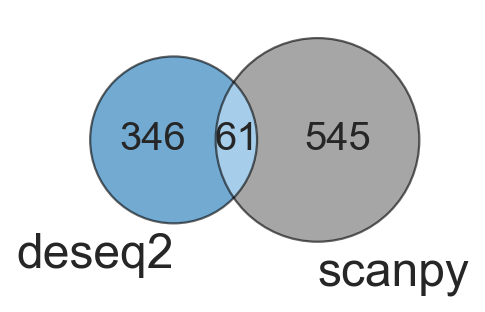

In [61]:
from matplotlib_venn import venn2, venn2_circles

A = up.index
B = deEN_up['names']

fig,ax = plt.subplots(figsize = (3,3))
venn2([set(A),set(B)],ax=ax, set_colors = [adata.uns[str(groups) + '_colors'][0] , 'grey'],set_labels = ['deseq2','scanpy'],
      alpha = 0.7)
c = venn2_circles([set(A),set(B)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

#plt.savefig('figs/venn3_neg.png',bbox_inches='tight')
plt.show()

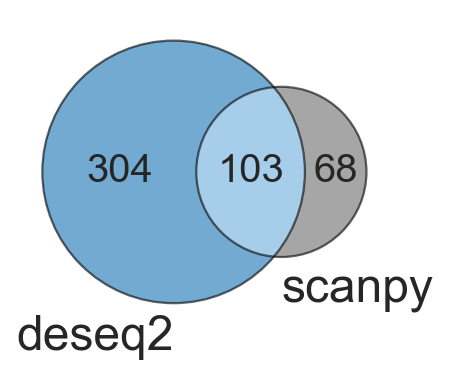

In [62]:
from matplotlib_venn import venn2, venn2_circles

A = up.index
B = deP_up['names']

fig,ax = plt.subplots(figsize = (3,3))
venn2([set(A),set(B)],ax=ax, set_colors = [adata.uns[str(groups) + '_colors'][0] , 'grey'],set_labels = ['deseq2','scanpy'],
      alpha = 0.7)
c = venn2_circles([set(A),set(B)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

#plt.savefig('figs/venn3_neg.png',bbox_inches='tight')
plt.show()

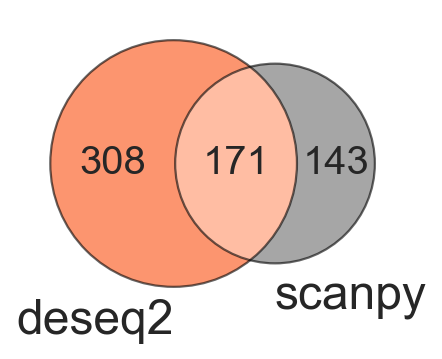

In [63]:
from matplotlib_venn import venn2, venn2_circles

A = down.index
B = deEC_up['names']

fig,ax = plt.subplots(figsize = (3,3))
venn2([set(A),set(B)],ax=ax, set_colors = [adata.uns[str(groups) + '_colors'][1] , 'grey'], set_labels = ['deseq2','scanpy'],
      alpha = 0.7)
c = venn2_circles([set(A),set(B)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)
#plt.savefig('figs/venn3_neg.png',bbox_inches='tight')
plt.show()

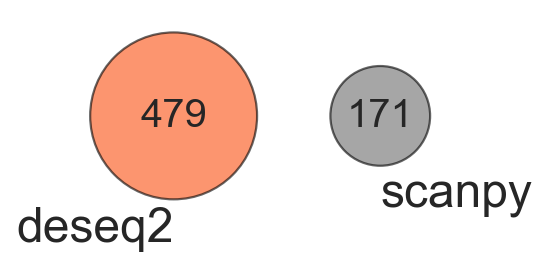

In [64]:
from matplotlib_venn import venn2, venn2_circles

A = down.index
B = deP_up['names']

fig,ax = plt.subplots(figsize = (3,3))
venn2([set(A),set(B)],ax=ax, set_colors = [adata.uns[str(groups) + '_colors'][1] , 'grey'], set_labels = ['deseq2','scanpy'],
      alpha = 0.7)
c = venn2_circles([set(A),set(B)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)
#plt.savefig('figs/venn3_neg.png',bbox_inches='tight')
plt.show()

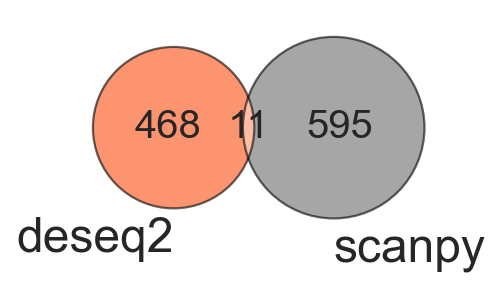

In [65]:
from matplotlib_venn import venn2, venn2_circles

A = down.index
B = deEN_up['names']

fig,ax = plt.subplots(figsize = (3,3))
venn2([set(A),set(B)],ax=ax, set_colors = [adata.uns[str(groups) + '_colors'][1] , 'grey'], set_labels = ['deseq2','scanpy'],
      alpha = 0.7)
c = venn2_circles([set(A),set(B)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)
#plt.savefig('figs/venn3_neg.png',bbox_inches='tight')
plt.show()

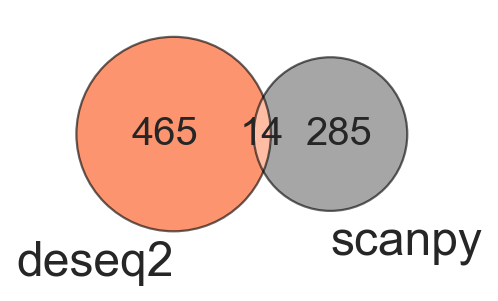

In [66]:
from matplotlib_venn import venn2, venn2_circles

A = down.index
B = deM_up['names']

fig,ax = plt.subplots(figsize = (3,3))
venn2([set(A),set(B)],ax=ax, set_colors = [adata.uns[str(groups) + '_colors'][1] , 'grey'], set_labels = ['deseq2','scanpy'],
      alpha = 0.7)
c = venn2_circles([set(A),set(B)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)
#plt.savefig('figs/venn3_neg.png',bbox_inches='tight')
plt.show()

# all plots for diff expressed genes

In [67]:
def makeVolcano(df, df_up, df_down, lfc = 'log2FoldChange'):
    fig,ax = plt.subplots(figsize = (4,4))
    
    sns.scatterplot(data = df,
                   x = lfc,s=12,edgecolor = None,
                   y = 'p_log10',alpha = 0.4,
                   c = 'grey')
    
    sns.scatterplot(data = df_up,
                   x = lfc,s=12,edgecolor = None,
                   y = 'p_log10',
                   c = adata.uns[str(groups) + '_colors'][0] )
    
    sns.scatterplot(data = df_down,
                   x = lfc,s=12,edgecolor = None,
                   y = 'p_log10',
                   c = adata.uns[str(groups) + '_colors'][1] )
    ax.legend([],frameon=False)
    ax.set_ylabel('log10 [p-value]')
    ax.set_xlabel('log2 FC')
    
    
    #plt.savefig('figs/volcanoes_diffexpressed.png', bbox_inches='tight')
    plt.show()

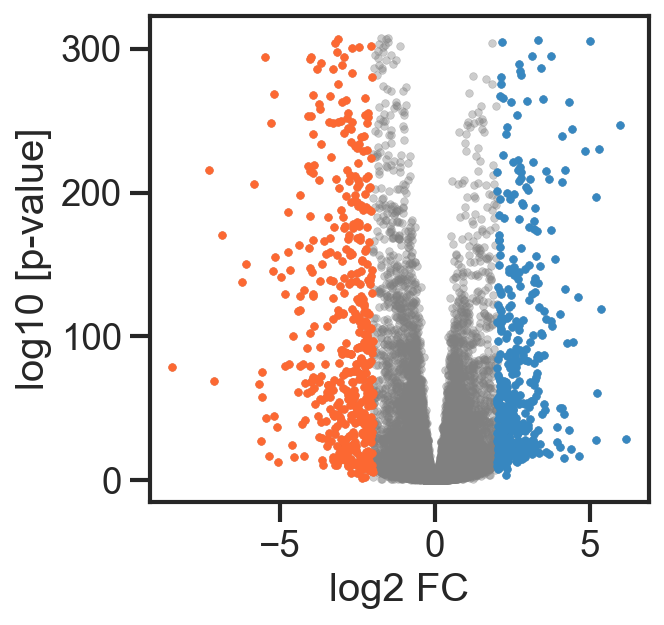

In [68]:
makeVolcano(results_df,up,down)

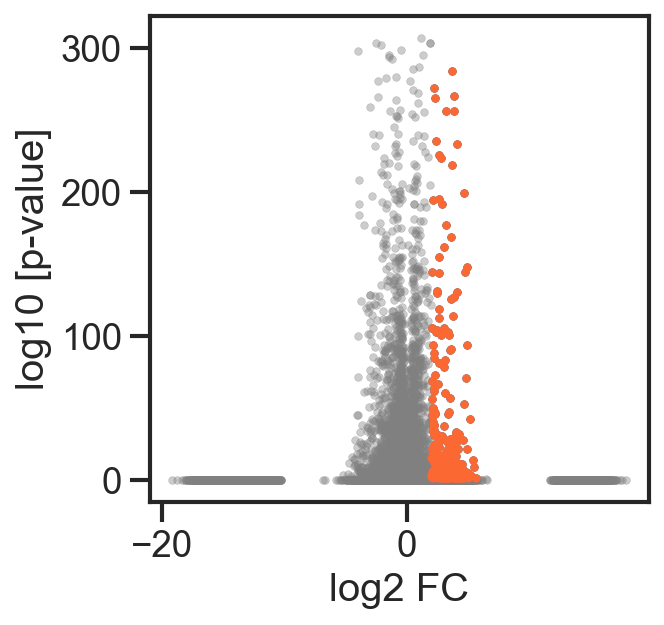

In [69]:
makeVolcano(deM,deM_up,deM_up)

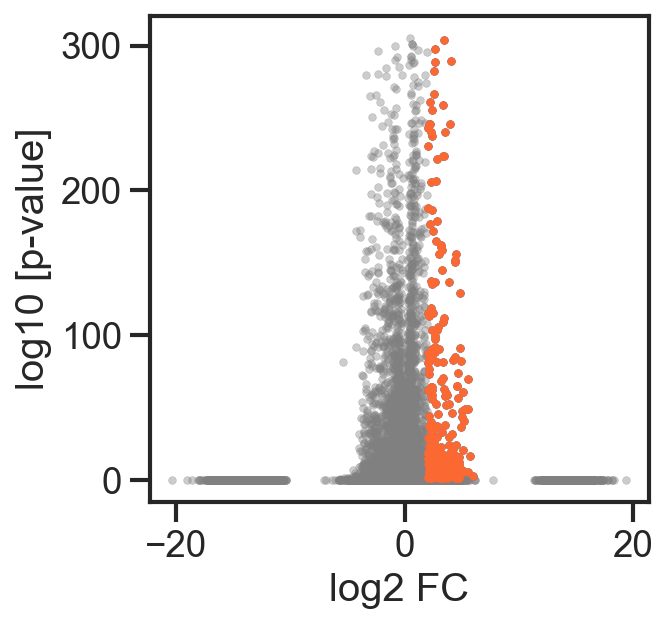

In [70]:
makeVolcano(deEC,deEC_up,deEC_up)

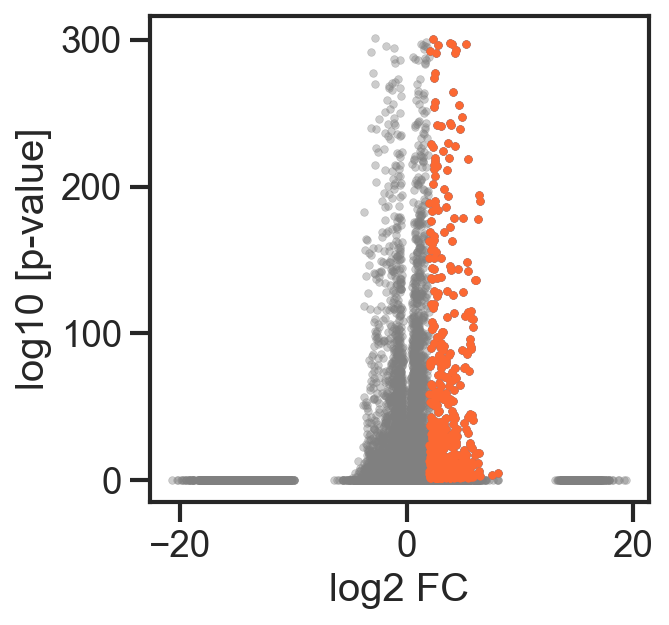

In [71]:
makeVolcano(deEN,deEN_up,deEN_up)

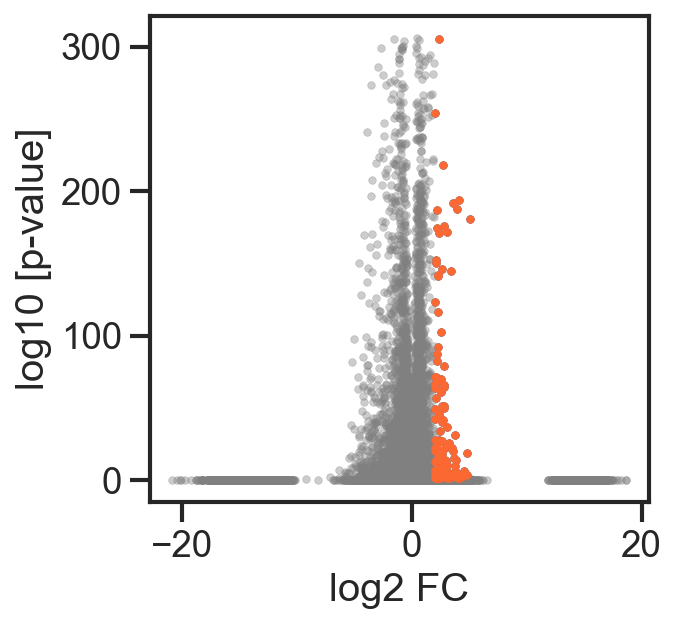

In [72]:
makeVolcano(deP,deP_up,deP_up)

In [73]:
allgenes = list(results_df.index.unique())
def plotGO(genelist, reflist, n = 10, save = None, source = 'GO:BP'):
    plotcl = sc.queries.enrich({'cluster':genelist,
                   'all':reflist}, org="mmusculus")
    cluster = 'cluster'
    plot1 = plotcl[plotcl['query'] == cluster][plotcl[plotcl['query'] == cluster]['source'] == source].sort_values(by='p_value')[['name','p_value']][0:n]
    plot1['-log (p-value)'] = np.log10(plot1['p_value'])*-1
    sns.set_style('ticks')
    sns.set_context('talk')
    fig,ax = plt.subplots(figsize = (6,3))
    ax = sns.barplot(y=plot1['name'],x=plot1['-log (p-value)'], ax=ax,color = 'grey')
    ax.set_ylabel('')
    if save != None:
        plt.savefig(save , bbox_inches='tight')
    #sns.despine()
    plt.show()

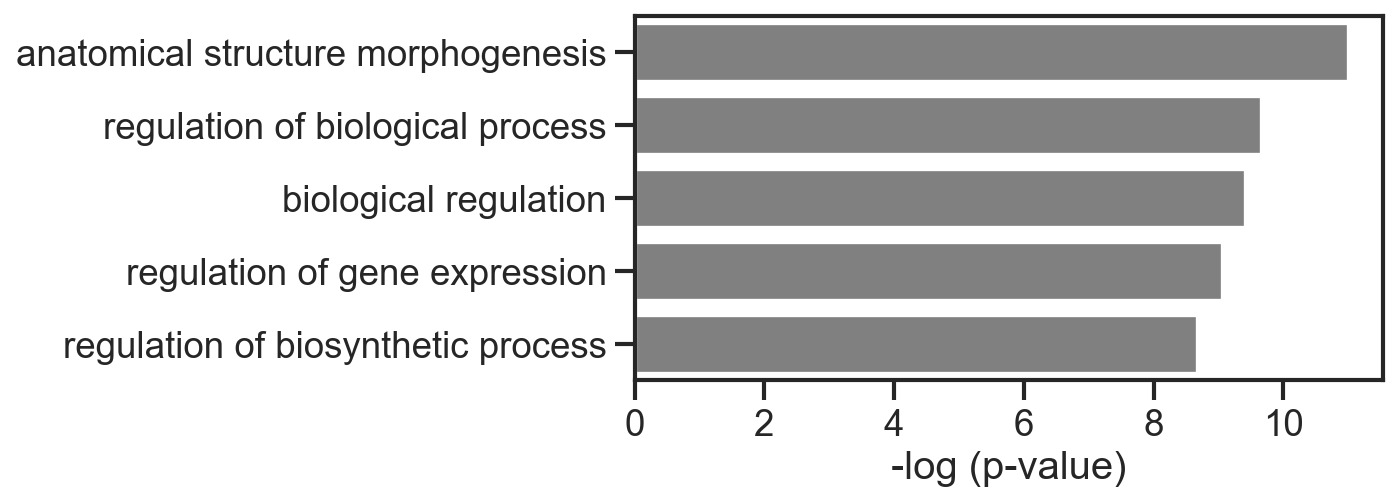

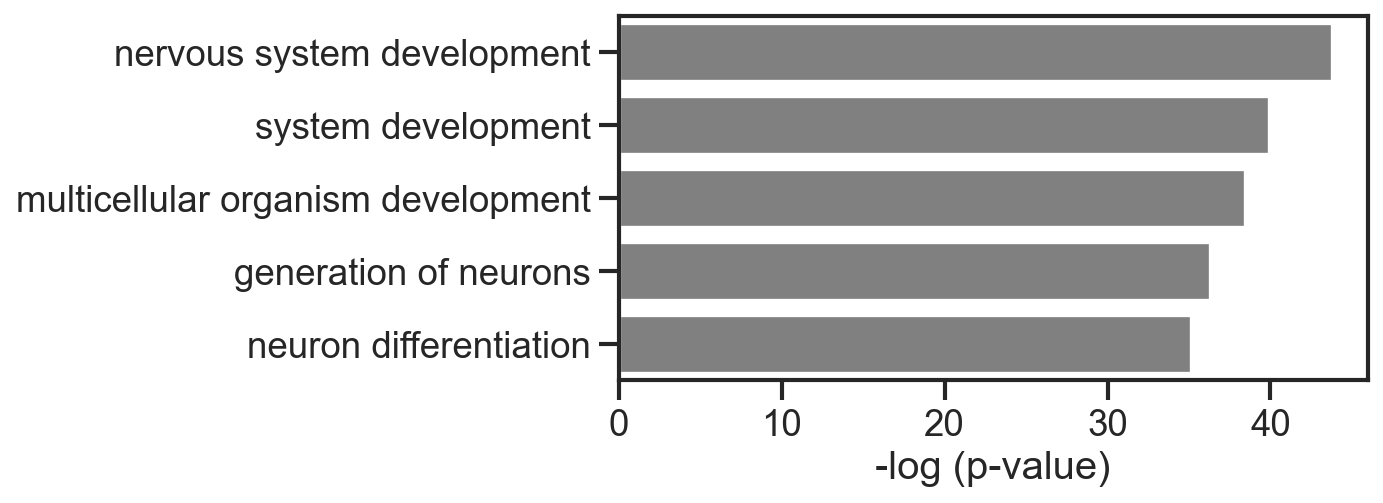

In [74]:
plotGO(list(up.index),allgenes, n = 5)
plotGO(list(down.index),allgenes, n = 5)

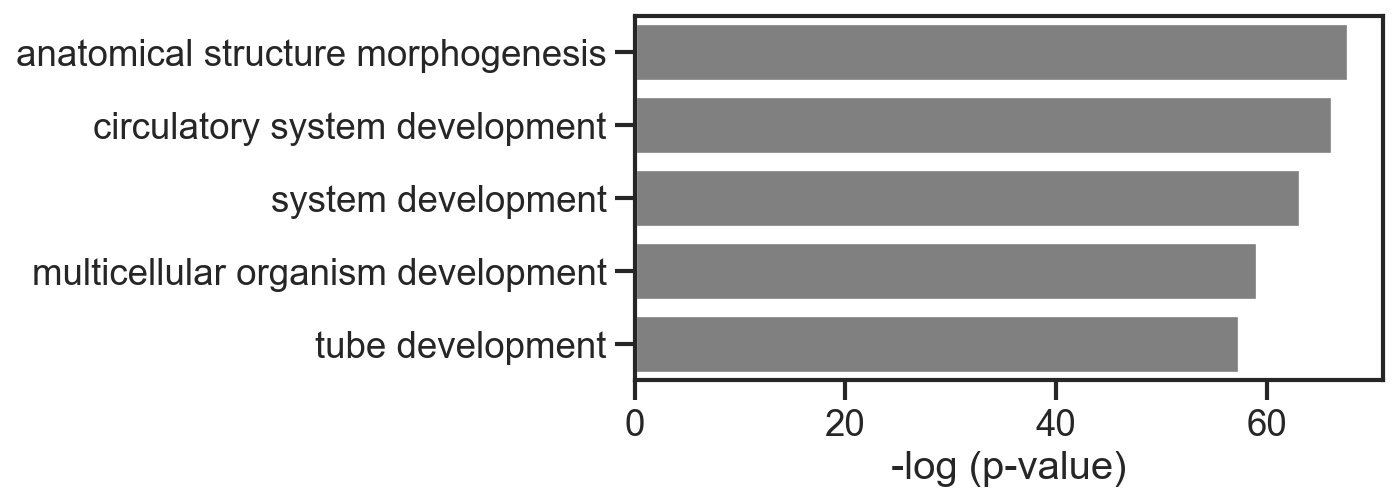

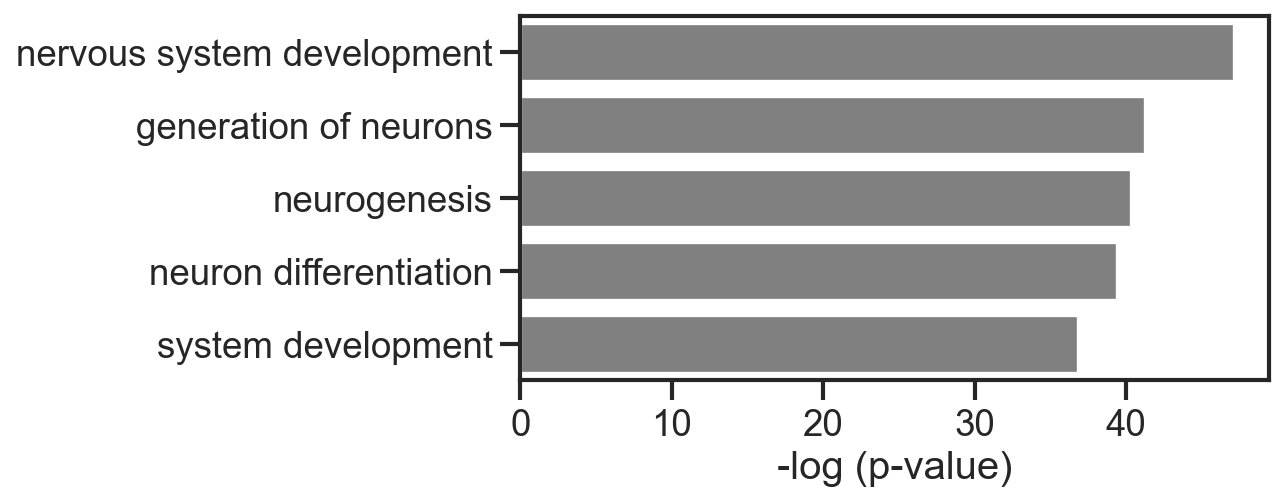

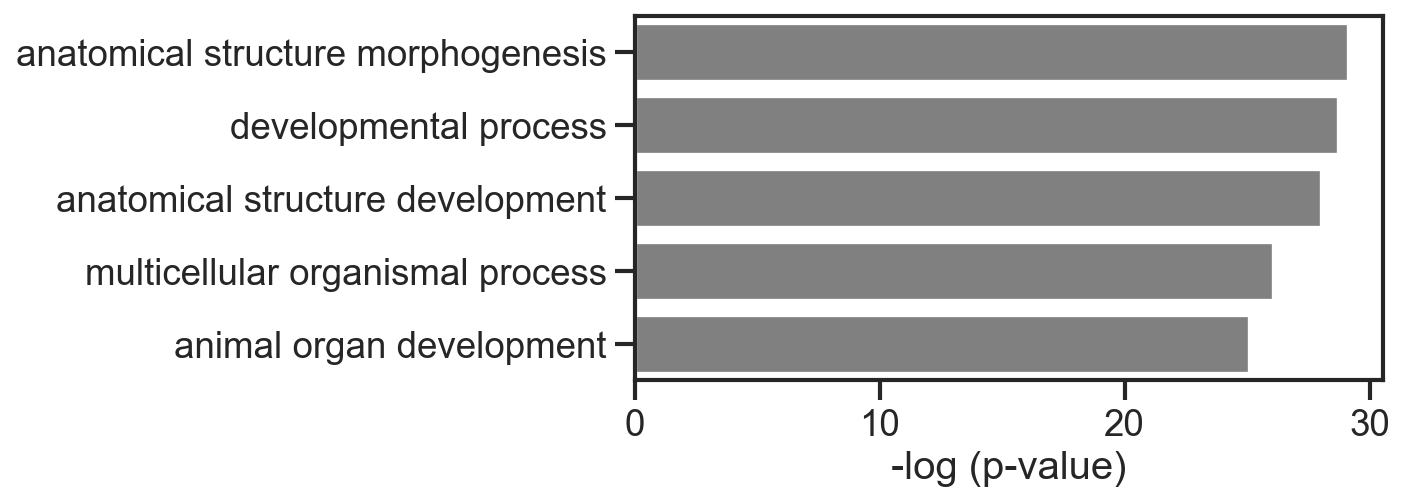

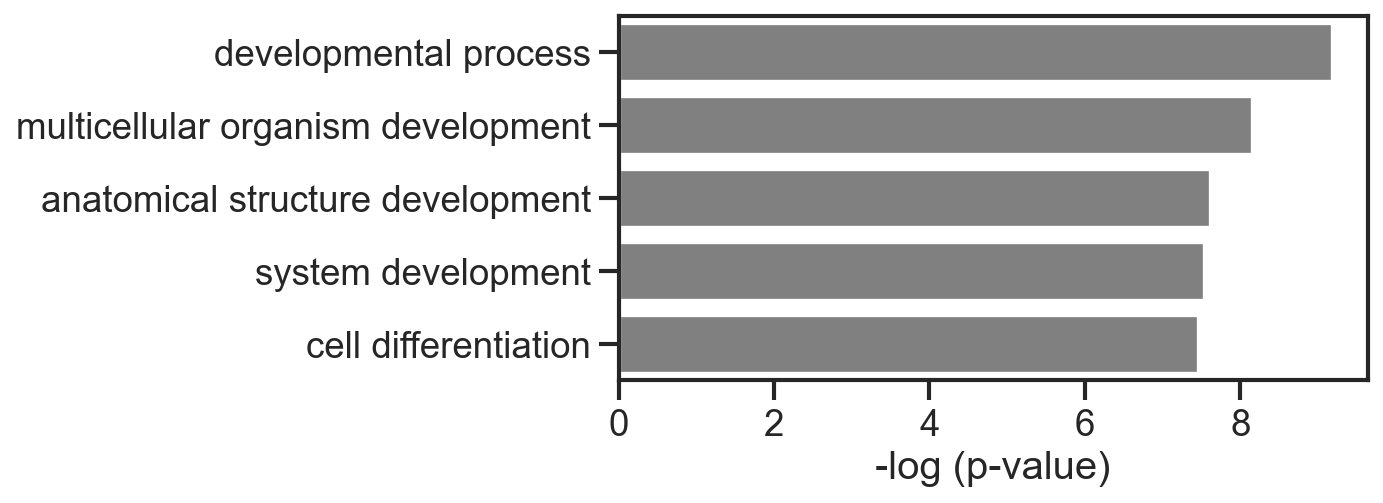

In [75]:
plotGO(list(deM_up['names']),allgenes, n = 5)
plotGO(list(deEC_up['names']),allgenes, n = 5)
plotGO(list(deEN_up['names']),allgenes, n = 5)
plotGO(list(deP_up['names']),allgenes, n = 5)

## Gene regulatory network analysis

In [76]:
# Retrieve CollecTRI gene regulatory network
collectri = dc.get_collectri(organism='mouse', split_complexes=False,)

collectri.head(2)

/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/liana/resource/_orthology.py:199: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,source,target,weight
0,AP1,Aanat,1
1,AP1,Abca1,-1


In [77]:
def plotTFs(df, save = None):
    mat = df[['stat']].T.rename(index={'stat': 'diff'})
    tf_acts, tf_pvals = dc.run_ulm(mat=mat, net=collectri)
    dc.plot_barplot(
    acts=tf_acts,
    contrast='diff',
    top=25,
    vertical=True,
    figsize=(3, 6)
    )
    if save != None:
        plt.savefig(save, bbox_inches = 'tight')
    plt.show()

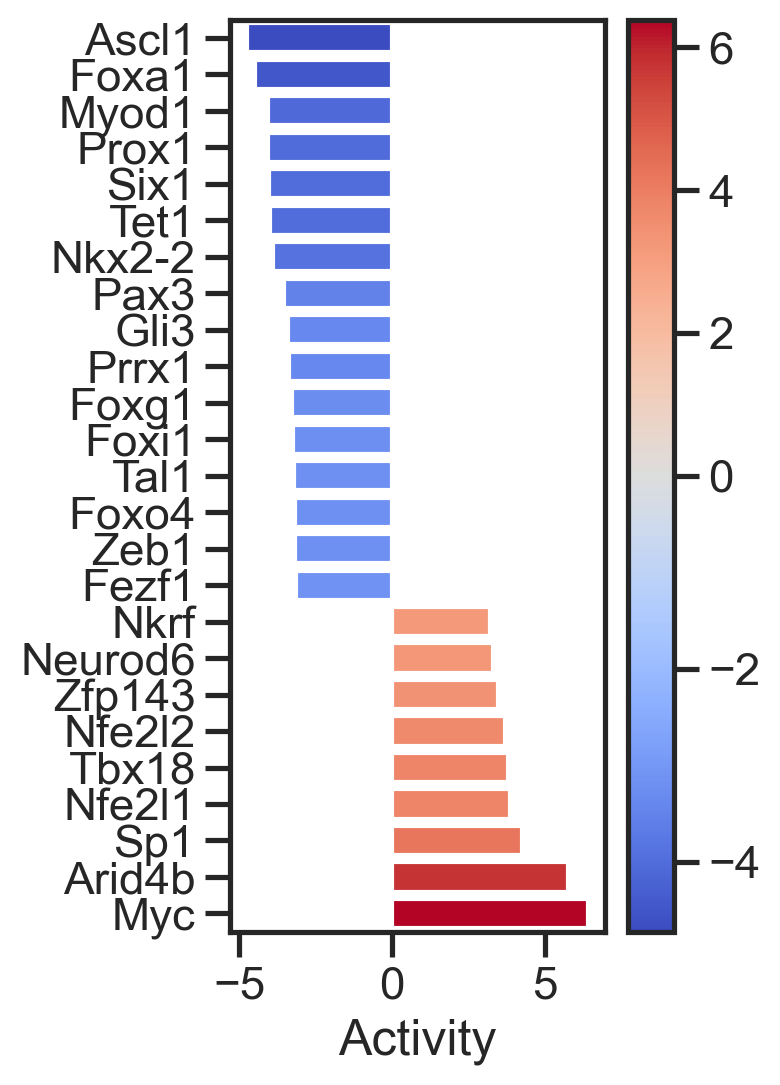

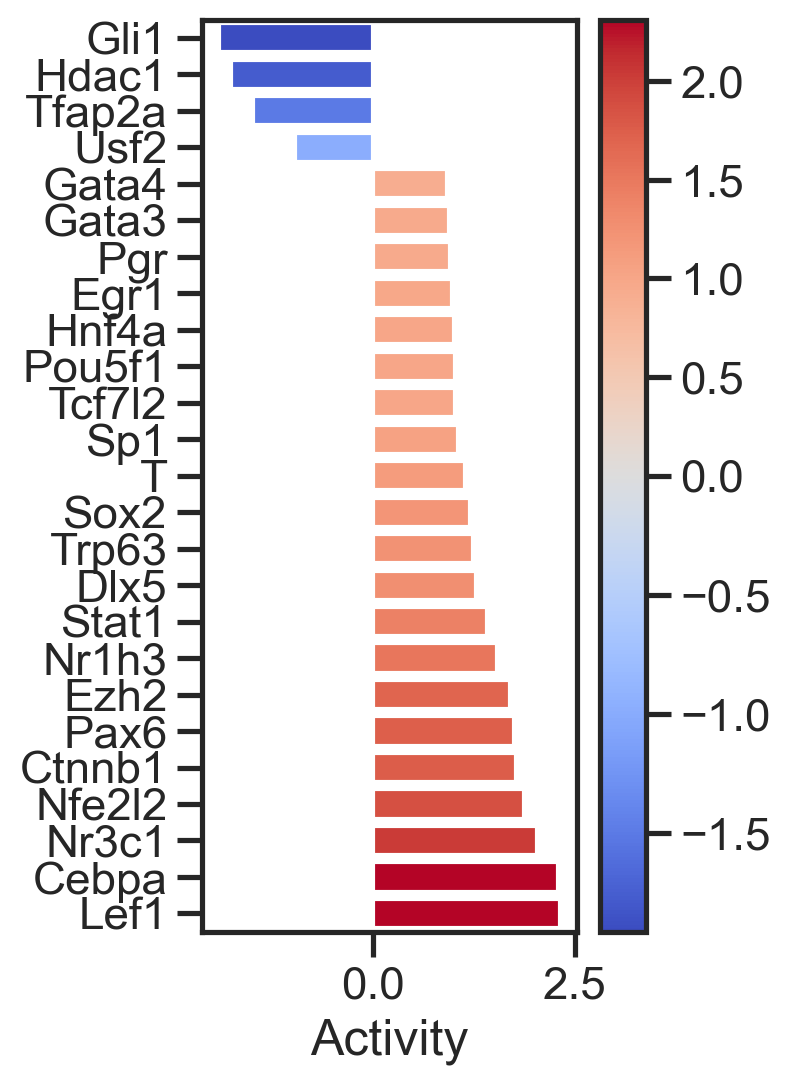

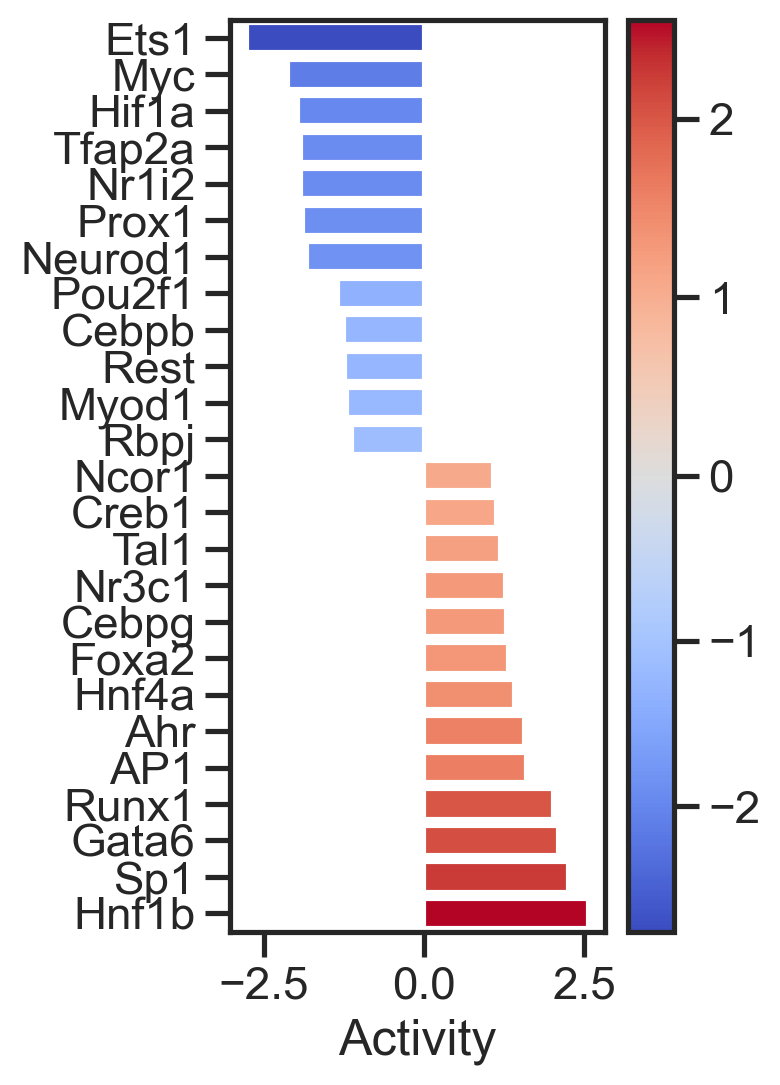

In [78]:
plotTFs(results_df)
plotTFs(up)
plotTFs(down)

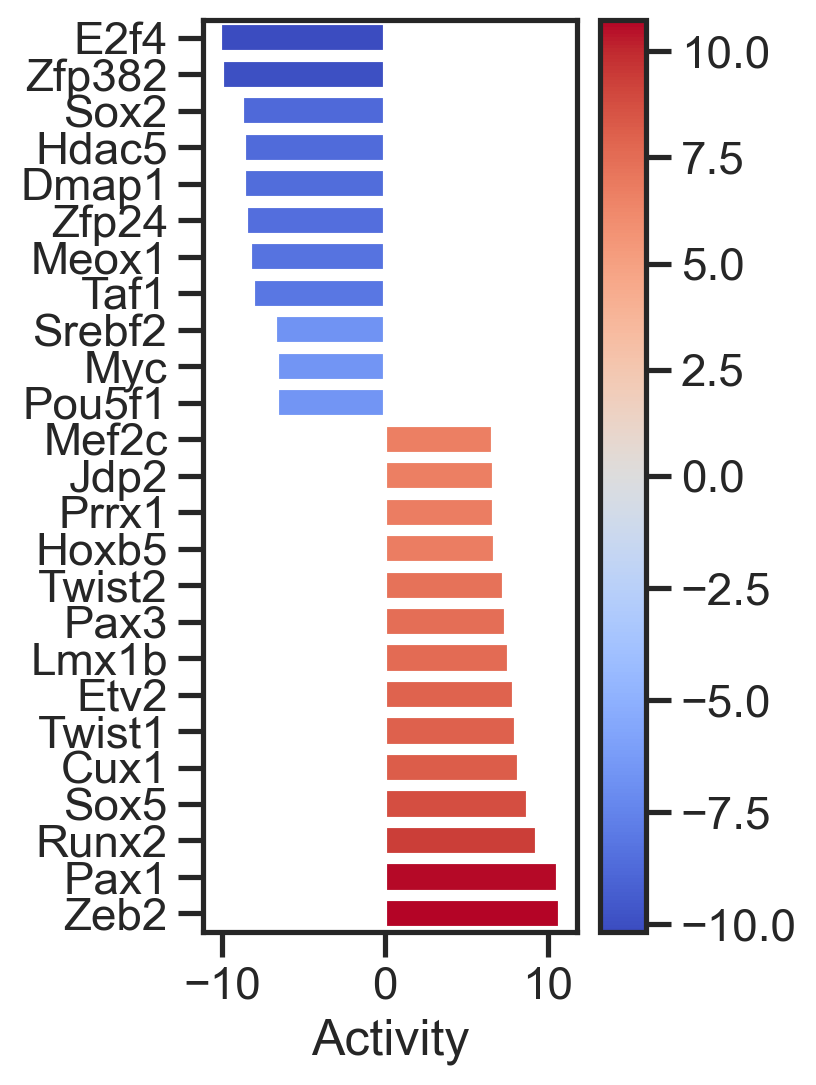

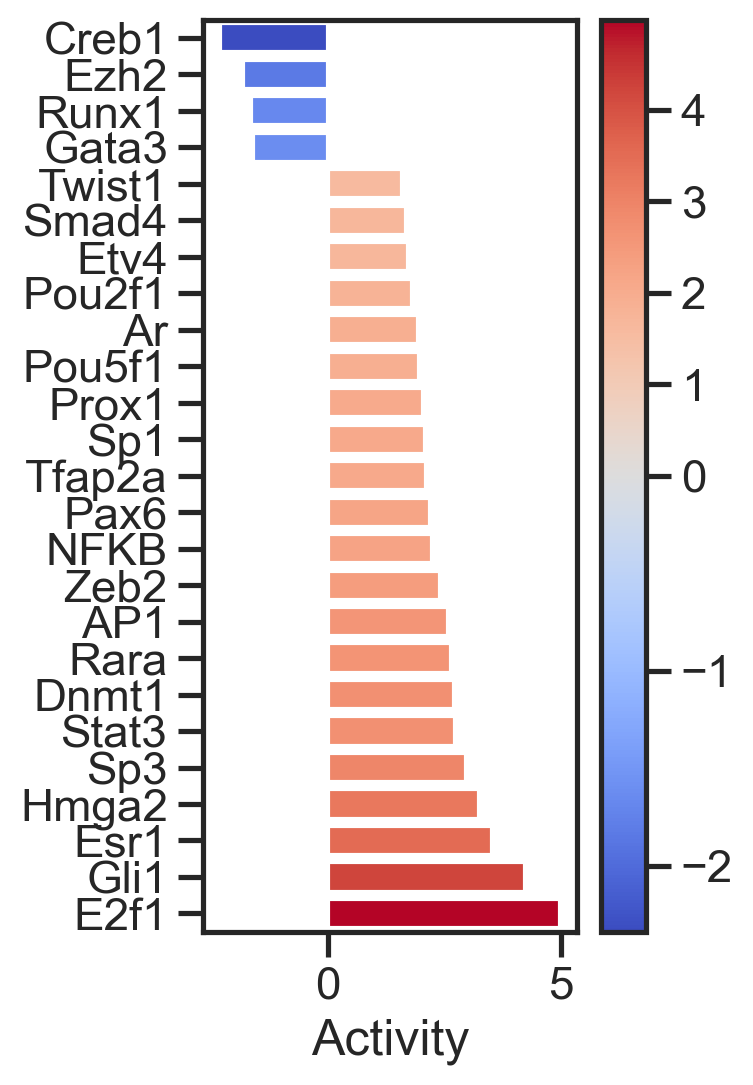

In [79]:
plotTFs(deM)
plotTFs(deM_up)

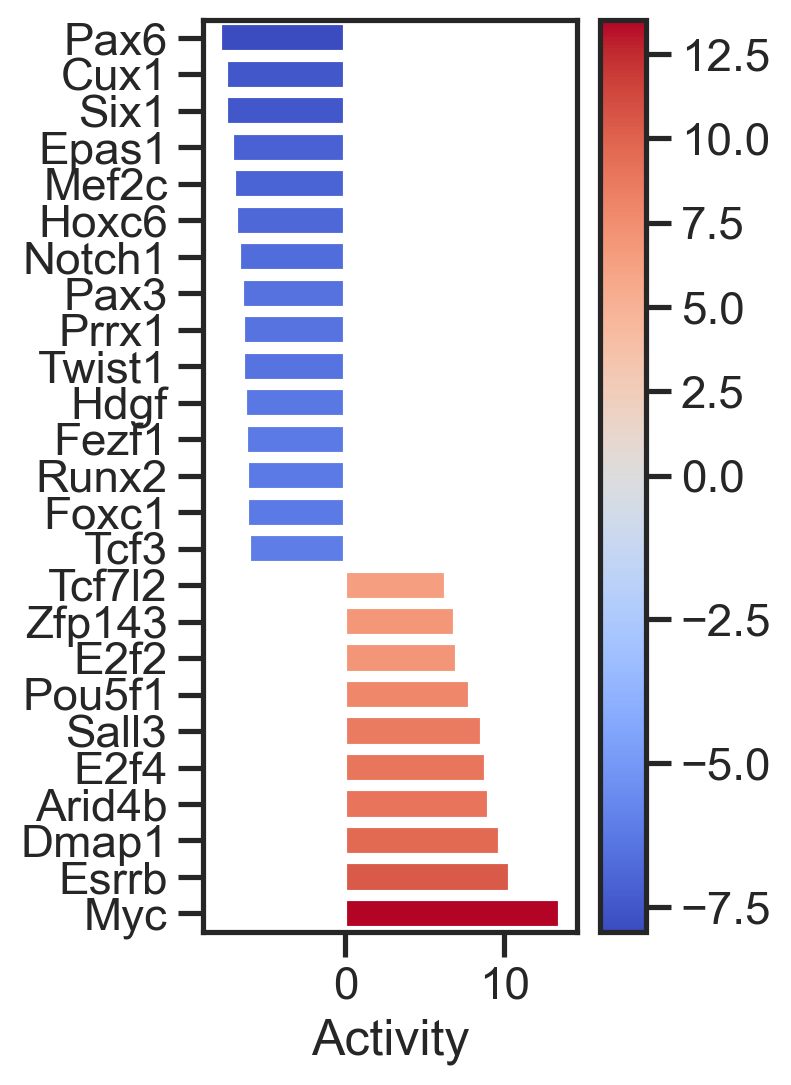

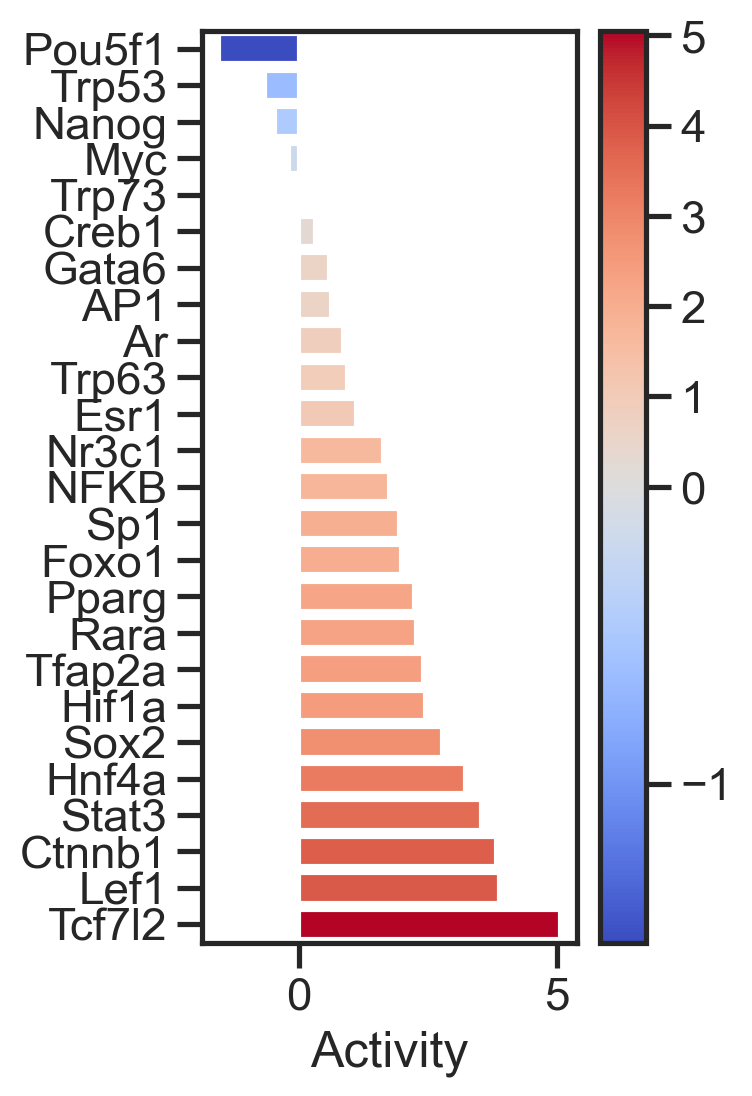

In [80]:
plotTFs(deP)
plotTFs(deP_up)

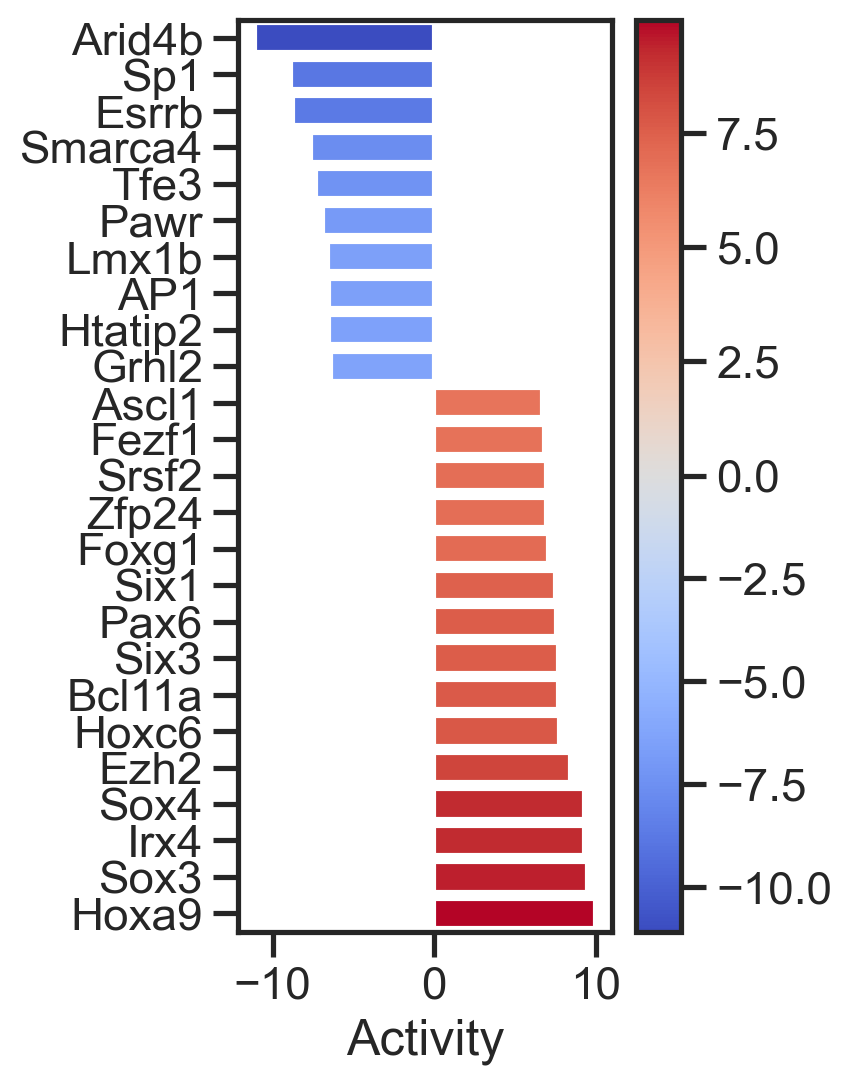

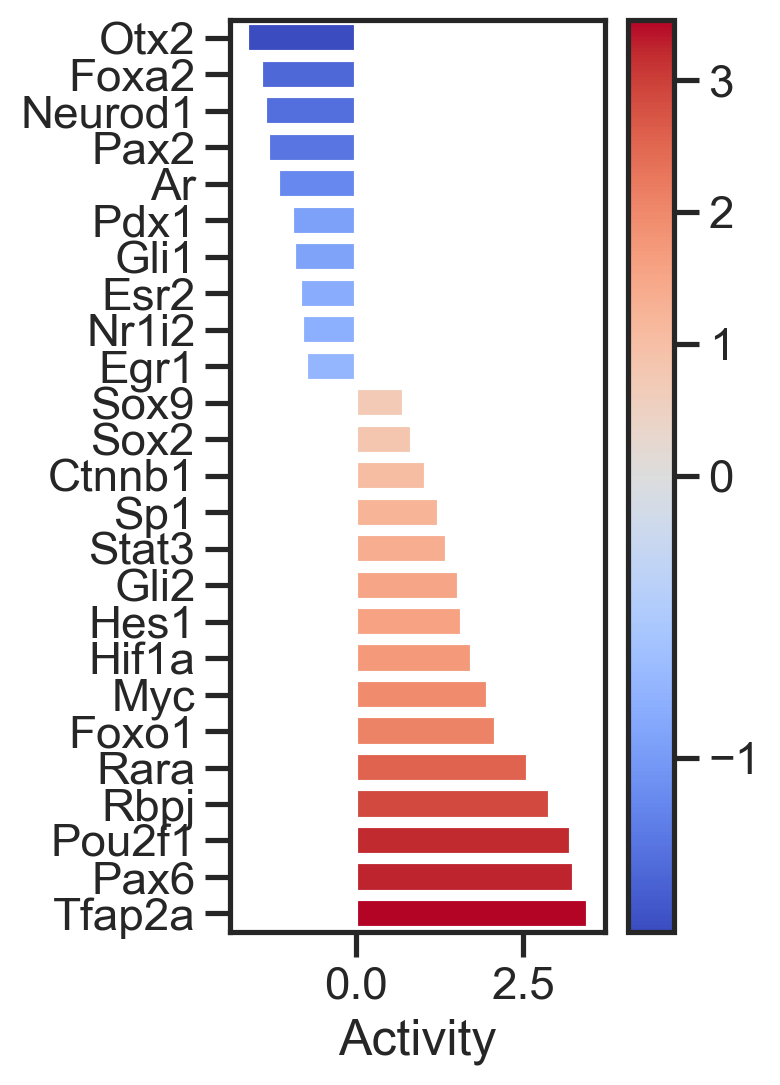

In [81]:
plotTFs(deEC)
plotTFs(deEC_up)

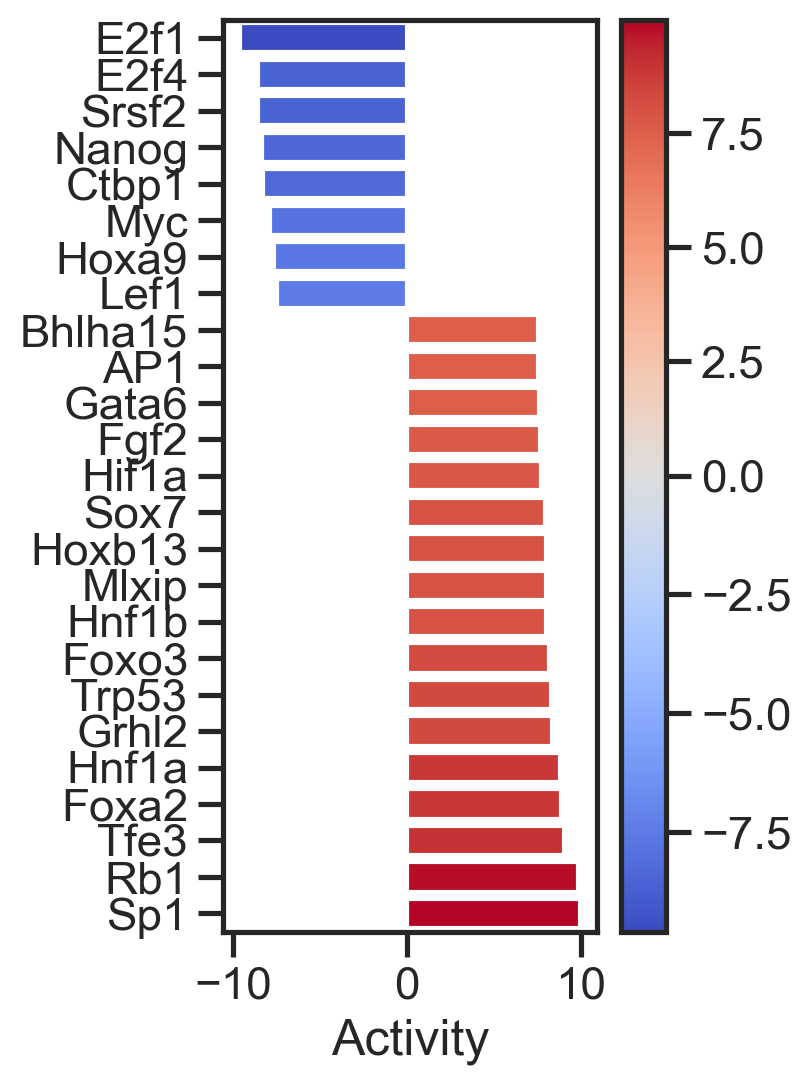

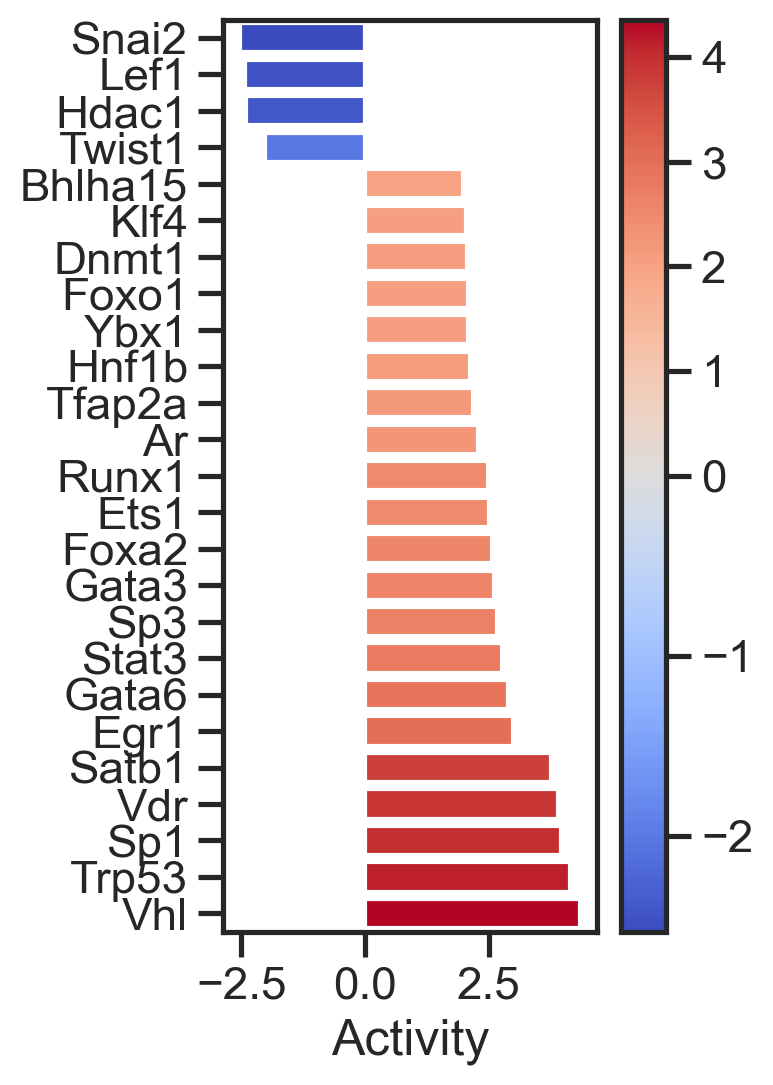

In [82]:
plotTFs(deEN)
plotTFs(deEN_up)

## conclusions: deseq can only do comparisons of 2 groups at a time, whereas scanpy can do for n groups: group_n vs rest. The two results are therefore not comparable here - deseq only did pluripotent vs ectoderm.(see overlap of 'up' with scanpy's pluriptent genes and 'down' with scanpy's ectoderm genes). The scanpy results seem alright - it extracts decent GO terms and expected TFs

So we have 2 options for pluripotent vs lineages:
(1) we can do 4x deseq: \
(A) pluripotent vs all 3, for pluripotent (PvsDIFF) \
(B) pluripotent vs ectoderm, for ectoderm (PvsECT) \
(C) pluripotent vs endoderm, for endoderm (PvsEND) \
(D) pluripotent vs mesoderm, for mesoderm (PvsMES) 

(2) we do the standard scanpy, where we calculate 4x group_n vs rest in one analysis. This gives the results like above

* For ESC vs Pluripotent, i would still do the deseq approach (see corresponding notebook in the same folder)
* i will still generate the notebooks for approach (1) so we can properly compare, with the notebook names abbreviated as above